# Show Reel — Comment **Sentiment** Analysis (Vertex AI **Batch** + **Multimodal**)

Per-comment, multilingual **sentiment & affect** analysis run as a Vertex AI **batch** job.
Comments are grouped **by post**, so each request carries that post's media (images / video
frames + transcript + metadata) as *shared context* — letting the model tell a sincere
*"bellissima"* from a sarcastic one, and pin down **what** each comment is reacting to.

* **Platform-aware** — set `PLATFORM`; the platform is named in every prompt for context.
* **Multimodal** (Instagram) — the post's media is attached once per request, shared by all its comments.
* **Rich labels** — sentiment, score, emotion, intensity, sarcasm, toxicity, intent, target, language.
* **Fire-and-forget** — `submit_sentiment()`, close the laptop, `retrieve_sentiment()` later.
* Mirrors `persona_pipeline.ipynb` infra (same client, media bridge, batch helpers).

## Install Dependencies

In [241]:
!pip install -q google-genai google-cloud-storage gcsfs pandas pyarrow tqdm matplotlib

## Configuration

In [242]:
import os

# ============================ PLATFORM TOGGLE ============================
PLATFORM = "instagram"        # instagram | youtube | tiktok | facebook
# ========================================================================

# GCP / Vertex AI
GCP_PROJECT_ID = "gen-lang-client-0792749758"
GCP_LOCATION   = "us-central1"
GCS_BUCKET     = "afb_showreel"

# Prepared comments (ALL platforms; filtered to PLATFORM at load)
COMMENTS_ML_PATH  = f"gs://{GCS_BUCKET}/Preped_Comments/comments_ml.parquet"
COMMENTS_LLM_PATH = f"gs://{GCS_BUCKET}/Preped_Comments/comments_llm.jsonl"

# Multimodal context (Instagram only)
MEDIA_INDEX_PATH = f"gs://{GCS_BUCKET}/ig_multimodal_final.parquet"
MEDIA_GCS_PREFIX = "multimodal_dataset_fixed/"
ATTACH_MEDIA     = (PLATFORM == "instagram")

# ── MODEL TIERS ──────────────────────────────────────────────────────────────
# Flash -> high-volume zero-shot comment classification (THIS pipeline).
# Pro   -> reserved for persona consolidation in persona_pipeline.ipynb (stage 1).
MODEL_SENTIMENT = "gemini-2.5-flash"   # DO NOT switch to Pro here; volume is prohibitive.

# Generation config
TEMPERATURE       = 0.0
TOP_P             = 1.0
MAX_OUTPUT_TOKENS = 8192
THINKING_BUDGET   = 512   # light reasoning aids sarcasm/irony detection; 0 to disable

# Batching
COMMENTS_PER_REQUEST   = 50
MAX_COMMENTS           = None   # None = ALL
PRIORITIZE_MEDIA_POSTS = True
SAMPLE_SEED            = 42

# Media attachment caps (cost control)
MAX_IMAGES_PER_POST  = 8
MAX_FRAMES_PER_VIDEO = 11
INCLUDE_TRANSCRIPT   = True
MAX_TRANSCRIPT_CHARS = 2000
MAX_TEXT_CHARS       = 500

# GCS batch I/O
BATCH_INPUT_PREFIX    = "sentiment_batch/input/"
BATCH_OUTPUT_PREFIX   = "sentiment_batch/output/"
POLL_INTERVAL_SECONDS = 60

# Local artifacts
LOCAL_DIR     = "outputs"
MANIFEST_PATH = f"{LOCAL_DIR}/sentiment_manifest.json"
RESULTS_PATH  = f"{LOCAL_DIR}/sentiment_{PLATFORM}.parquet"
ROOM_LLM_PATH = f"{LOCAL_DIR}/room_llm_{PLATFORM}.parquet"
ROOM_PATH     = f"{LOCAL_DIR}/room_vibe_{PLATFORM}.parquet"

# |score| <= NEUTRAL_BAND -> "neutral"  (used in retrieve_sentiment + room vibe cells)
NEUTRAL_BAND = 0.15

os.makedirs(LOCAL_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Platform : {PLATFORM}  (media: {'ON' if ATTACH_MEDIA else 'OFF'})")
print(f"  Model    : {MODEL_SENTIMENT}  (Pro reserved for persona_pipeline.ipynb)")
print(f"  Cap      : {MAX_COMMENTS} comments | {COMMENTS_PER_REQUEST}/request")
print(f"  Neutral  : +/-{NEUTRAL_BAND}")


Configuration loaded.
  Platform : instagram  (media: ON)
  Model    : gemini-2.5-flash  (Pro reserved for persona_pipeline.ipynb)
  Cap      : None comments | 50/request
  Neutral  : +/-0.15


## Vertex AI Client (google-genai)

In [243]:
from __future__ import annotations
from typing import Literal, Optional
from pydantic import BaseModel, Field
from google import genai
from google.genai.types import CreateBatchJobConfig, JobState

client = genai.Client(vertexai=True, project=GCP_PROJECT_ID, location=GCP_LOCATION)

# ---------------------------------------------------------------------------
# Step 1: Pydantic Structural Contract
# ---------------------------------------------------------------------------
# SentimentItem field order is deliberate:
#   i          -> index anchor (maps comment back to the prompt list)
#   reasoning  -> chain-of-thought scratchpad; forces the model to commit
#                 to its analysis BEFORE emitting any label tokens
#   <labels>   -> all enum/float fields follow after the reasoning anchor
#
# "mixed" removed from sentiment: ambiguity belongs in score ∈ (-0.3, 0.3),
# not in a fourth categorical class that the classifier can hide behind.
# ---------------------------------------------------------------------------

class SentimentItem(BaseModel):
    i:         int
    reasoning: str = Field(
        ...,
        description=(
            "≤40 words of chain-of-thought: sarcasm verdict, target, "
            "then sentiment rationale. Written BEFORE any label is emitted."
        ),
    )
    sentiment: Literal["positive", "negative", "neutral"]
    score:     float = Field(
        ..., ge=-1.0, le=1.0,
        description="-1.0 = very negative, 0.0 = neutral, +1.0 = very positive",
    )
    emotion:   Literal[
        "joy", "trust", "fear", "surprise",
        "sadness", "disgust", "anger", "anticipation", "neutral"
    ]
    intensity: Literal["low", "medium", "high"]
    sarcasm:   bool
    toxicity:  Literal["none", "mild", "severe"]
    intent:    Literal[
        "praise", "affection", "support", "criticism",
        "question", "suggestion", "tag_share", "spam_promo", "joke", "other"
    ]
    target:    Literal[
        "creator", "appearance", "content_work", "product",
        "other_user", "off_topic", "none"
    ]
    lang:      str = Field(..., description="ISO-639-1, e.g. it, en")


class RoomRead(BaseModel):
    vibe: Literal[
        "celebratory", "supportive", "appreciative", "amused",
        "mixed", "debated", "divided", "critical",
        "hostile", "spam_heavy", "neutral"
    ]
    consensus:             float = Field(..., ge=0.0, le=1.0)
    alignment:             float = Field(..., ge=-1.0, le=1.0)
    controversy:           float = Field(..., ge=0.0, le=1.0)
    sponsorship_alignment: float = Field(..., ge=0.0, le=1.0)
    split_axis:            Optional[str] = Field(
        None, description="<=5 words naming the dividing axis, or null if room is united"
    )
    dominant_stance: str
    summary:         str


class SentimentResponse(BaseModel):
    req:   str
    items: list[SentimentItem]
    room:  RoomRead


# ---------------------------------------------------------------------------
# Step 2: Vertex AI Schema Sanitizer
# ---------------------------------------------------------------------------

def _sanitize_schema(schema: dict) -> dict:
    """
    Flatten Pydantic v2 $defs/$ref for Vertex AI OpenAPI 3.0 subset.

    Two fixes applied recursively:
      1. $ref resolution  — Vertex does not follow $ref in batch JSONL;
                            inline the definition directly.
      2. enum type injection — Vertex silently falls back to free-text
                               generation when an enum node lacks "type".
                               Inject "type": "string" whenever "enum" is
                               present and "type" is absent.
      3. key stripping    — "title" and "$schema" are rejected by Vertex.
    """
    defs = schema.pop("$defs", {})

    def _resolve(node: object) -> object:
        if isinstance(node, dict):
            # 1. Resolve $ref before anything else
            if "$ref" in node:
                ref_name = node["$ref"].split("/")[-1]
                return _resolve(defs.get(ref_name, node))

            resolved = {
                k: _resolve(v)
                for k, v in node.items()
                if k not in ("title", "$schema")
            }

            # 2. Inject "type": "string" when enum is present but type is absent
            if "enum" in resolved and "type" not in resolved:
                resolved["type"] = "string"

            return resolved

        if isinstance(node, list):
            return [_resolve(v) for v in node]

        return node

    return _resolve(schema)


def get_batch_generation_config_dict() -> dict:
    """
    Returns the fully json.dumps()-serializable generationConfig for one
    Vertex Batch JSONL line.

    Hard-coded decisions:
      temperature=0.0   — deterministic; avoids stochastic label drift
      thinkingBudget=512 — enough for sarcasm/irony reasoning without
                           eating into the 8192-token output budget
      topP omitted       — irrelevant at temperature=0; fewer keys = fewer
                           Vertex validation surface errors
    """
    raw_schema   = SentimentResponse.model_json_schema()
    clean_schema = _sanitize_schema(raw_schema)

    return {
        "temperature":      0.0,
        "maxOutputTokens":  MAX_OUTPUT_TOKENS,
        "responseMimeType": "application/json",
        "responseSchema":   clean_schema,
        "thinkingConfig":   {"thinkingBudget": THINKING_BUDGET},
    }


import logging
log = logging.getLogger("sentiment_pipeline")
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")

log.info("genai Vertex client ready: %s  %s", GCP_PROJECT_ID, GCP_LOCATION)
log.info("Pydantic models + get_batch_generation_config_dict() ready.")


[INFO] genai Vertex client ready: gen-lang-client-0792749758  us-central1
[INFO] Pydantic models + get_batch_generation_config_dict() ready.


## Data Loading

Comment **features** come from `comments_ml` (filtered to `PLATFORM`); **raw text** is joined
in from `comments_llm` by `comment_id`. Instagram also loads the media index that bridges
`media_id ↔ shortcode` and carries post metadata.

In [244]:
import pandas as pd
import os
import gcsfs

def _comments_loaded() -> bool:
    try:
        df = globals()["comments"]
    except KeyError:
        return False
    if not isinstance(df, pd.DataFrame) or df.empty:
        return False
    if "platform" in df.columns and df["platform"].iloc[0] != PLATFORM:
        return False
    if "text" not in df.columns:
        return False
    mi = globals().get("media_index", "__missing__")
    if ATTACH_MEDIA and mi is None:
        return False
    if not ATTACH_MEDIA and mi != "__missing__" and mi is not None:
        return False
    return True

def _get_local(gcs_path, local_dir=LOCAL_DIR):
    local_path = os.path.join(local_dir, gcs_path.split("/")[-1])
    if not os.path.exists(local_path):
        print(f"  Downloading {gcs_path} -> {local_path} ...")
        fs = gcsfs.GCSFileSystem()
        fs.get(gcs_path, local_path)
    return local_path

if _comments_loaded():
    print(
        f"[data] already loaded for platform={PLATFORM!r} — skipping GCS reads.\n"
        f"  comments: {len(comments):,} | authors: {comments['author_id'].nunique():,} "
        f"| posts: {comments['media_id'].nunique():,}\n"
        f"  media_index: {'loaded' if media_index is not None else 'OFF'}"
    )
else:
    print(f"[data] loading prepared comments for platform={PLATFORM!r} ...")

    local_ml_path = _get_local(COMMENTS_ML_PATH)
    local_llm_path = _get_local(COMMENTS_LLM_PATH)

    # 1) Comment feature matrix — predicate-pushdown filter to PLATFORM (skips other platforms).
    comments = pd.read_parquet(local_ml_path, filters=[("platform", "==", PLATFORM)])
    comments["author_id"] = comments["author_id"].astype(str)
    comments["media_id"]  = comments["media_id"].astype(str)
    print(f"  comments_ml[{PLATFORM}]: {len(comments):,} comments | "
          f"{comments['author_id'].nunique():,} authors | {comments['media_id'].nunique():,} posts")

    # 2) Raw text for EVERY comment (comments_llm has no author_id -> join by comment_id).
    print(f"  loading text from {local_llm_path} ...")
    _chunks = []
    for _c in pd.read_json(local_llm_path, lines=True, chunksize=200_000):
        if "platform" in _c.columns:
            _c = _c[_c["platform"] == PLATFORM]
        if len(_c):
            _chunks.append(_c[["comment_id", "text"]])
    llm_text = pd.concat(_chunks, ignore_index=True) if _chunks else pd.DataFrame(columns=["comment_id", "text"])
    comments = comments.merge(llm_text, on="comment_id", how="left")
    comments["text"] = comments["text"].fillna("").astype(str)
    print(f"  text attached to {(comments['text'].str.len() > 0).sum():,}/{len(comments):,} comments")

    # 3) Instagram-only multimodal context: post metadata + media index (bare-numeric media_id).
    if ATTACH_MEDIA:
        local_media_path = _get_local(MEDIA_INDEX_PATH)
        media_index = pd.read_parquet(local_media_path)
        media_index = media_index[media_index["media_id"].notna()].copy()
        media_index["media_id"] = media_index["media_id"].astype(str)
        print(f"  media_index: {len(media_index):,} posts | {media_index['shortcode'].nunique():,} shortcodes")
    else:
        media_index = None
        print(f"  media context OFF for platform={PLATFORM} -> text-only run")

    # 4) Keep only comments that actually have text to analyse.
    _before = len(comments)
    comments = comments[comments["text"].str.strip() != ""].reset_index(drop=True)
    print(f"\n[data] ready: {len(comments):,}/{_before:,} comments with text")


[data] already loaded for platform='instagram' — skipping GCS reads.
  comments: 499,752 | authors: 194,513 | posts: 1,501
  media_index: loaded


## Multimodal Media Context

One `list_blobs` pass builds a shortcode→images / shortcode→transcript manifest. For a post,
`build_post_media_parts(media_id)` returns the **metadata text + sampled images/frames +
transcript** (never the mp4), per the media-form directive. The same media is attached once
per request and shared by every comment on that post.

In [245]:
import re
import numpy as np
from google.cloud import storage

def _norm_id(x):
    """media_id can arrive as int, float (123.0) or str — normalise to a bare digit string."""
    s = str(x)
    return s[:-2] if s.endswith(".0") else s


# Whisper segment markers like "[0.00s -> 7.00s]" carry no sentiment signal -> strip them.
_TS_RE = re.compile(r"\[\s*\d+(?:\.\d+)?\s*s\s*->\s*\d+(?:\.\d+)?\s*s\s*\]")
def _clean_transcript(raw: str) -> str:
    """Drop the [t -> t] timestamps and collapse whitespace. Returns '' for no-speech clips
    (music/ambient-only videos where Whisper emits just a '.' or a stray char) so we don't send noise."""
    txt = re.sub(r"\s+", " ", _TS_RE.sub(" ", raw)).strip()
    return txt if sum(ch.isalpha() for ch in txt) >= 4 else ""

if not ATTACH_MEDIA:
    media_images, media_transcripts = {}, {}
    _mediaid_to_shortcode, _meta_by_shortcode = {}, {}
    posts_with_media = set()
    def build_post_media_parts(media_id) -> list:
        return []
    print(f"⏭  Media disabled for platform={PLATFORM}; requests will be text-only.")
else:
    # 1) media index maps (bare-numeric media_id matches comments_ml.media_id)
    _mi = media_index.copy()
    _mi["media_id"] = _mi["media_id"].map(_norm_id)
    _mediaid_to_shortcode = dict(zip(_mi["media_id"], _mi["shortcode"]))
    _meta_by_shortcode    = {r["shortcode"]: r for r in _mi.to_dict("records")}

    # 2) GCS media manifest — one list pass over the whole media tree
    def build_media_manifest(bucket=GCS_BUCKET, prefix=MEDIA_GCS_PREFIX):
        c = storage.Client(project=GCP_PROJECT_ID)
        images, transcripts = {}, {}
        for blob in c.list_blobs(bucket, prefix=prefix):
            name = blob.name
            low  = name.lower()
            segs = name.split("/")            # multimodal_dataset_fixed/<form>/<shortcode>/...
            if len(segs) < 3:
                continue
            sc  = segs[2]
            uri = f"gs://{bucket}/{name}"
            if low.endswith((".jpg", ".jpeg", ".png")):
                images.setdefault(sc, []).append(uri)
            elif low.endswith(".txt") and "transcri" in low:
                transcripts.setdefault(sc, []).append(uri)
        for d in (images, transcripts):
            for k in d:
                d[k].sort()
        print(f"✅ manifest: {len(images):,} posts with images, {len(transcripts):,} with transcripts.")
        return images, transcripts

    media_images, media_transcripts = build_media_manifest()
    posts_with_media = {mid for mid, sc in _mediaid_to_shortcode.items() if sc in media_images}

    # 3) builders
    _transcript_cache = {}
    def fetch_transcript(sc: str) -> str:
        if sc in _transcript_cache:
            return _transcript_cache[sc]
        chunks = []
        c = storage.Client(project=GCP_PROJECT_ID)
        for uri in media_transcripts.get(sc, [])[:8]:        # carousel_video has one per slide
            try:
                chunks.append(storage.Blob.from_string(uri, client=c).download_as_text())
            except Exception:
                pass
        t = _clean_transcript(" ".join(x.strip() for x in chunks if x.strip()))
        _transcript_cache[sc] = t
        return t

    def _pick_images(sc: str, k: int):
        """Evenly sample k image URIs across the post (spread frames/slides, not the first k)."""
        uris = media_images.get(sc, [])
        if len(uris) <= k:
            return uris
        step = len(uris) / k
        return [uris[int(i * step)] for i in range(k)]

    def _txt(v):
        return v.strip() if isinstance(v, str) else ""

    def _as_list_str(v):
        if isinstance(v, (list, tuple, np.ndarray)):
            return ", ".join(str(x) for x in v if str(x) not in ("nan", "None", ""))
        return _txt(v)

    def format_post_meta_text(sc: str) -> str:
        row  = _meta_by_shortcode.get(sc, {})
        cf   = _txt(row.get("content_form"))
        bits = [f"POST [{cf or 'post'}] shortcode={sc}"]
        cap  = _txt(row.get("caption"))
        if cap:
            bits.append(f"caption: {cap[:300]}")
        tg = _as_list_str(row.get("tagged_usernames"))
        if tg:
            bits.append(f"tagged: {tg}")
        co = _as_list_str(row.get("coauthors"))
        if co:
            bits.append(f"coauthors: {co}")
        song, artist, atype = _txt(row.get("song_title")), _txt(row.get("artist")), _txt(row.get("audio_type"))
        if song or artist:
            bits.append(f"music: {song} - {artist} ({atype})")
        loc = _txt(row.get("location_name"))
        if loc:
            bits.append(f"location: {loc}")
        return " | ".join(bits)

    _VIDEO_FORMS = {"reel", "carousel_video", "video", "igtv", "feed_video"}
    def _img_cap(sc: str) -> int:
        """Reels/videos -> MAX_FRAMES_PER_VIDEO keyframes; photos/carousels -> MAX_IMAGES_PER_POST slides."""
        row = _meta_by_shortcode.get(sc, {})
        cf = _txt(row.get("content_form")).lower()
        is_video = bool(row.get("has_frames")) or cf in _VIDEO_FORMS or (row.get("n_mp4") or 0) > 0
        return MAX_FRAMES_PER_VIDEO if is_video else MAX_IMAGES_PER_POST

    def build_post_media_parts(media_id) -> list:
        """Media payload for a single post: metadata text + sampled images/frames + transcript.
        image/carousel -> photos; reel/feed/carousel_video -> frames + transcript (never the mp4)."""
        sc = _mediaid_to_shortcode.get(_norm_id(media_id))
        if not sc or sc not in media_images:
            return []
        parts = [{"text": "POST MEDIA CONTEXT — " + format_post_meta_text(sc)}]
        for uri in _pick_images(sc, _img_cap(sc)):
            parts.append({"fileData": {"fileUri": uri, "mimeType": "image/jpeg"}})
        if INCLUDE_TRANSCRIPT:
            t = fetch_transcript(sc)
            if t:
                parts.append({"text": "transcript: " + t[:MAX_TRANSCRIPT_CHARS]})
        return parts

    print(f"✅ media bridge ready. Posts with media available: {len(posts_with_media):,}")

✅ manifest: 1,473 posts with images, 367 with transcripts.
✅ media bridge ready. Posts with media available: 1,470


## Batch Infrastructure

Same helpers as the persona pipeline: write JSONL → upload to GCS → `client.batches.create`
→ (poll) → download sharded `predictions.jsonl`. `record_batch_job` / `get_recorded_job`
make it fire-and-forget across kernel restarts.

In [246]:
import json, os, time, datetime, re
from google.cloud import storage

def strip_fences(s: str) -> str:
    s = s.strip()
    s = re.sub(r"^```(?:json)?\s*", "", s)
    s = re.sub(r"\s*```$", "", s)
    return s.strip()

def write_jsonl(lines: list, path: str) -> str:
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for obj in lines:
            if isinstance(obj, str):
                f.write(obj + "\n")
            else:
                f.write(json.dumps(obj, ensure_ascii=False, separators=(',', ':')) + "\n")
    print(f"[prep] wrote {len(lines):,} requests -> {path}")
    return path

def upload_to_gcs(local_path: str, bucket_name: str, blob_name: str) -> str:
    c = storage.Client(project=GCP_PROJECT_ID)
    c.bucket(bucket_name).blob(blob_name).upload_from_filename(local_path)
    uri = f"gs://{bucket_name}/{blob_name}"
    print(f"[upload] {local_path} -> {uri}")
    return uri

def submit_batch_job(input_uri: str, output_uri: str, model: str):
    """Non-blocking submit. dest is a PREFIX; Vertex writes a unique run subfolder under it."""
    job = client.batches.create(
        model=model, src=input_uri,
        config=CreateBatchJobConfig(dest=output_uri),
    )
    print(f"[submit] {model} -> {job.name}  ({job.state})")
    return job

def poll_until_complete(job_name: str):
    terminal = {JobState.JOB_STATE_SUCCEEDED, JobState.JOB_STATE_FAILED,
                JobState.JOB_STATE_CANCELLED, JobState.JOB_STATE_PAUSED}
    while True:
        job = client.batches.get(name=job_name)
        print(f"[poll {datetime.datetime.now():%H:%M:%S}] state = {job.state}")
        if job.state in terminal:
            return job
        time.sleep(POLL_INTERVAL_SECONDS)

def retrieve_response_texts(job, bucket_name: str) -> list:
    """Download every output shard and return the model's text per row (None for failed rows)."""
    out_loc = job.dest.gcs_uri
    prefix  = out_loc.replace(f"gs://{bucket_name}/", "")
    c  = storage.Client(project=GCP_PROJECT_ID)
    bk = c.bucket(bucket_name)
    blobs = [b for b in bk.list_blobs(prefix=prefix) if b.name.endswith(".jsonl")]
    texts = []
    bad_lines = 0
    for blob in blobs:
        for line in blob.download_as_text().splitlines():
            if not line.strip():
                continue
            try:
                rec  = json.loads(line)
            except json.JSONDecodeError as e:
                log.warning("malformed JSON line (char %d): skipping", e.pos)
                bad_lines += 1
                texts.append(None)
                continue
            resp = rec.get("response")
            if not resp:
                texts.append(None)
                continue
            try:
                parts = resp["candidates"][0]["content"]["parts"]
                texts.append("".join(p.get("text", "") for p in parts))
            except (KeyError, IndexError):
                texts.append(None)
    if bad_lines > 0:
        log.warning("retrieve: skipped %d malformed JSON lines", bad_lines)
    print(f"[retrieve] {len(texts):,} response rows from {len(blobs)} shard(s) ({bad_lines} bad lines)")
    return texts

def record_batch_job(tag: str, job, dest: str) -> dict:
    """Persist a submitted job so a LATER run (even a fresh kernel) can retrieve it."""
    rec = {"name": job.name, "dest": dest, "state": str(job.state),
           "submitted_at": datetime.datetime.now().isoformat()}
    with open(f"{LOCAL_DIR}/{tag}_job.json", "w", encoding="utf-8") as f:
        json.dump(rec, f, indent=2)
    print(f"[record] {tag} job -> {LOCAL_DIR}/{tag}_job.json")
    return rec

def get_recorded_job(tag: str):
    """Re-fetch the live job for a recorded submission (raises if none recorded)."""
    p = f"{LOCAL_DIR}/{tag}_job.json"
    if not os.path.exists(p):
        raise FileNotFoundError(f"No submitted '{tag}' job recorded at {p} — submit it first.")
    with open(p, encoding="utf-8") as f:
        rec = json.load(f)
    job = client.batches.get(name=rec["name"])
    print(f"[{tag}] {rec['name']} -> {job.state}")
    return job

print("✅ Batch infrastructure ready.")


✅ Batch infrastructure ready.


## Sentiment Requests (Batch · Multimodal)

Each request = the platform-aware system prompt + one post's media + a numbered list of that
post's comments (with compact feature hints). The model returns one rich label per comment,
keyed by the integer `i` we assign, wrapped under the request id `req` so results can be joined
back regardless of output order (Vertex batch order is **not** guaranteed). A persisted
`manifest` maps `req` + `i` → `comment_id`, so retrieval works even from a fresh kernel.

In [247]:
import json
import logging
import numpy as np
from tqdm import tqdm

log = logging.getLogger("sentiment_pipeline")


# ---------------------------------------------------------------------------
# System Prompt
# ---------------------------------------------------------------------------
# Design principles:
#   - Zero manual JSON stringification: field names are described in prose.
#   - Reasoning anchor: the model MUST emit the "reasoning" field first.
#     Because the schema enforces field order, all label tokens are generated
#     AFTER the scratchpad is committed — preventing label bleeding.
#   - Raw-valence extraction: the LLM labels true emotional valence of text
#     regardless of target. Brand-equity isolation is handled downstream in
#     calculate_brand_equity_scores() via vectorized Pandas, not prompt rules.
#   - Sarcasm-first gate: irony resolution happens before any label is
#     written, not as an afterthought.
# ---------------------------------------------------------------------------

def sentiment_system_prompt(platform: str) -> str:
    return (
        # ── Role ──────────────────────────────────────────────────────────────
        f"You are an expert multilingual social-media sentiment analyst "
        f"specialising in Italian influencer content on {platform.upper()}. "
        f"Comments you receive were posted under a single post. Many are in "
        f"Italian; expect slang, abbreviations, mixed languages, and emoji.\n\n"

        # ── Media context ─────────────────────────────────────────────────────
        f"MEDIA CONTEXT: When POST MEDIA CONTEXT is provided (images, video "
        f"frames, transcript, metadata), you MUST use it. The same phrase can "
        f"be sincere praise on a glamour post or cutting sarcasm on a fail "
        f"video. Let the media anchor your interpretation of ambiguous comments.\n\n"

        # ── Reasoning process ─────────────────────────────────────────────────
        f"REASONING PROCESS — write your reasoning field FIRST. Work through "
        f"these five steps in order before committing to any label:\n\n"

        f"  1. SARCASM CHECK\n"
        f"     Is the surface meaning the opposite of intent? Cues: hyperbole, "
        f"     ironic praise on a fail moment, emoji/word tone mismatch, "
        f"     deliberate understatement. If sarcastic, flip the inferred "
        f"     sentiment before labeling. Set sarcasm=true.\n\n"

        f"  2. TARGET CHECK\n"
        f"     Who or what is the comment actually directed at?\n"
        f"     — 'creator'       : the person posting\n"
        f"     — 'appearance'    : how the creator looks\n"
        f"     — 'content_work'  : the post itself, video, or brand deal work\n"
        f"     — 'product'       : a featured item or sponsor\n"
        f"     — 'other_user'    : a reply or attack directed at another commenter\n"
        f"     — 'off_topic'     : unrelated to the post or creator\n"
        f"     — 'none'          : no specific target\n\n"

        f"  3. SENTIMENT LABEL\n"
        f"     Evaluate the raw, genuine sentiment of the text exactly as it is "
        f"     written, regardless of who the target is. If a user is furiously "
        f"     attacking another commenter, label the sentiment as 'negative' and "
        f"     the target as 'other_user'. Do NOT artificially force it to neutral. "
        f"     Emojis carry semantic weight — treat them as words. "
        f"     Assign score ∈ [-1.0, +1.0] and the matching categorical label: "
        f"     'positive' (score > 0.15), 'negative' (score < -0.15), "
        f"     'neutral' (|score| <= 0.15).\n\n"

        f"  4. EMOTION & INTENSITY\n"
        f"     Pick the single best-fit Plutchik core emotion: joy, trust, fear, "
        f"     surprise, sadness, disgust, anger, anticipation. Use 'neutral' "
        f"     only when no clear emotion is detectable. Assign intensity: "
        f"     low (mild expression), medium (clear emotion), high (strong/intense).\n\n"

        f"  5. ROOM READ\n"
        f"     After scoring all individual comments, read them holistically. "
        f"     Fill the room object: choose a vibe label, estimate consensus "
        f"     [0,1], alignment [-1,1], controversy [0,1], and "
        f"     sponsorship_alignment [0,1] (set 0.5 if post is not sponsored). "
        f"     split_axis: at most 5 words naming what divides the room, or null "
        f"     if the room is united. dominant_stance: one short phrase. "
        f"     summary: 1-2 sentences.\n\n"

        # ── Output ────────────────────────────────────────────────────────────
        f"OUTPUT: Return a single JSON object with no markdown, no preamble, "
        f"no explanation. Structure:\n"
        f'  {{"req": "<req_id>", '
        f'"items": [<one SentimentItem per comment>], '
        f'"room": <one RoomRead>}}\n\n'
        f"Each SentimentItem must have fields in this exact order: "
        f"i, reasoning, sentiment, score, emotion, intensity, sarcasm, "
        f"toxicity, intent, target, lang.\n"
        f"i matches the [index] shown before each comment in the prompt."
    )


# ---------------------------------------------------------------------------
# Feature-tag helper — compact numeric annotation prepended to each comment
# ---------------------------------------------------------------------------

_FEATS = [
    ("word_count",        "w"),
    ("emoji_count",       "e"),
    ("exclamation_count", "!"),
    ("question_count",    "?"),
    ("mention_count",     "@"),
    ("hashtag_count",     "#"),
]

def _feat_tag(row) -> str:
    bits = [f"{sym}{int(row[col])}" for col, sym in _FEATS
            if pd.notna(row.get(col)) and int(row.get(col, 0)) != 0]
    return ("[" + " ".join(bits) + "] ") if bits else ""


# ---------------------------------------------------------------------------
# Step 4: JSONL Line Builder
# ---------------------------------------------------------------------------
# Returns a raw JSON *string* (not a dict) so callers write directly:
#     f.write(line + "\n")
#
# generationConfig is retrieved once per line from get_batch_generation_config_dict()
# which embeds the fully-flattened, enum-typed responseSchema.  The schema
# is the hardware-level logit mask; the system prompt is the reasoning guide.
# Both must be consistent — changing one without the other causes drift.
# ---------------------------------------------------------------------------

def build_batch_jsonl_line(
    req_id:         str,
    comments_chunk: "pd.DataFrame",
    platform:       str,
    media_id=None,
) -> tuple[str, dict]:
    """
    Build one Vertex AI Batch JSONL request line.

    Returns:
        line_str      -- raw JSON string ready for `f.write(line_str + "\\n")`
        manifest_entry -- dict for the manifest keyed by req_id
    """
    parts: list[dict] = [{"text": sentiment_system_prompt(platform)}]

    # Attach post media parts when available (IG multimodal path)
    mparts    = build_post_media_parts(media_id) if (ATTACH_MEDIA and media_id is not None) else []
    parts.extend(mparts)
    has_media = bool(mparts)

    # Comment listing — indices [0]..[n-1] match the 'i' field in SentimentItem
    header = (
        f"\n--- COMMENTS TO ANALYSE "
        f"(req={req_id} | platform={platform.upper()} | "
        f"media_context={'yes' if has_media else 'no'}) ---"
    )
    lines_buf = [header]
    order: list[str] = []

    for i, (_, row) in enumerate(comments_chunk.iterrows()):
        order.append(row["comment_id"])
        text = str(row["text"])[:MAX_TEXT_CHARS].rstrip()
        lines_buf.append(f"[{i}] {_feat_tag(row)}{text}")

    parts.append({"text": "\n".join(lines_buf)})
    parts.append({
        "text": (
            f"\nReturn the JSON object with req='{req_id}', "
            f"one item per comment (i = 0..{len(comments_chunk) - 1}), "
            f"and one room read across all of them."
        )
    })

    gen_cfg = get_batch_generation_config_dict()

    payload = {
        "requests": [{
            "contents":       [{"role": "user", "parts": parts}],
            "generationConfig": gen_cfg,
        }]
    }

    # Serializability guard: raises TypeError here rather than at GCS upload time
    try:
        line_str = json.dumps(payload, ensure_ascii=False)
    except TypeError as exc:
        raise TypeError(
            f"[build_batch_jsonl_line] req={req_id} is not JSON-serializable: {exc}"
        ) from exc

    manifest_entry = {
        "req":         req_id,
        "media_id":    str(media_id) if media_id is not None else None,
        "has_media":   has_media,
        "comment_ids": order,
    }

    log.debug("built req=%s  comments=%d  media=%s", req_id, len(order), has_media)
    return line_str, manifest_entry


# ---------------------------------------------------------------------------
# Comment selection & request batching
# ---------------------------------------------------------------------------

def select_comments() -> "pd.DataFrame":
    df = comments
    if MAX_COMMENTS and len(df) > MAX_COMMENTS:
        if PRIORITIZE_MEDIA_POSTS and ATTACH_MEDIA and posts_with_media:
            mask = df["media_id"].map(_norm_id).isin(posts_with_media)
            df = pd.concat([
                df[mask].sample(frac=1, random_state=SAMPLE_SEED),
                df[~mask].sample(frac=1, random_state=SAMPLE_SEED),
            ]).head(MAX_COMMENTS)
        else:
            df = df.sample(n=MAX_COMMENTS, random_state=SAMPLE_SEED)
    return df.reset_index(drop=True)


def build_requests(df: "pd.DataFrame") -> tuple[list[str], dict]:
    """Returns list of raw JSONL line strings + manifest dict."""
    line_strings, manifest, rid = [], {}, 0
    for media_id, g in df.groupby("media_id", sort=False):
        for s in range(0, len(g), COMMENTS_PER_REQUEST):
            chunk  = g.iloc[s : s + COMMENTS_PER_REQUEST]
            req_id = f"R{rid}"
            line_str, man = build_batch_jsonl_line(req_id, chunk, PLATFORM, media_id)
            line_strings.append(line_str)
            manifest[req_id] = man
            rid += 1
    log.info("built %d JSONL lines for %d posts", len(line_strings), df["media_id"].nunique())
    return line_strings, manifest


# ---------------------------------------------------------------------------
# Submit / retrieve
# ---------------------------------------------------------------------------

def write_jsonl_strings(lines: list[str], path: str) -> str:
    """Write pre-serialized JSONL strings to disk; return path."""
    with open(path, "w", encoding="utf-8") as f:
        for line in lines:
            f.write(line + "\n")
    log.info("wrote %d JSONL lines -> %s", len(lines), path)
    return path


def submit_sentiment():
    df = select_comments()
    n_media = (
        df["media_id"].map(_norm_id).isin(posts_with_media).sum()
        if (ATTACH_MEDIA and posts_with_media) else 0
    )
    log.info(
        "SENTIMENT submit -- %s | %d comments | %d posts | %d with media | model: %s",
        PLATFORM, len(df), df["media_id"].nunique(), n_media, MODEL_SENTIMENT,
    )
    line_strings, manifest = build_requests(df)
    with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False)
    log.info("manifest: %d requests -> %s", len(manifest), MANIFEST_PATH)

    local_path = write_jsonl_strings(line_strings, f"{LOCAL_DIR}/sentiment_input.jsonl")
    in_uri  = upload_to_gcs(local_path, GCS_BUCKET, BATCH_INPUT_PREFIX + "sentiment_input.jsonl")
    out_uri = f"gs://{GCS_BUCKET}/{BATCH_OUTPUT_PREFIX}"
    job     = submit_batch_job(in_uri, out_uri, MODEL_SENTIMENT)
    record_batch_job("sentiment", job, out_uri)
    log.info("%d requests queued. Run retrieve_sentiment() when done.", len(line_strings))
    return job


def _as_bool(v):
    return v is True or str(v).strip().lower() in ("true", "1", "yes")


def retrieve_sentiment(save: bool = True) -> "pd.DataFrame":
    job = get_recorded_job("sentiment")
    if job.state != JobState.JOB_STATE_SUCCEEDED:
        log.warning("Not ready (state=%s). Re-run later.", job.state)
        return None
    with open(MANIFEST_PATH, encoding="utf-8") as f:
        manifest = json.load(f)
    rows, room_rows, bad = [], [], 0
    for t in retrieve_response_texts(job, GCS_BUCKET):
        if not t:
            bad += 1; continue
        try:
            obj = json.loads(strip_fences(t))
        except Exception:
            bad += 1; continue
        man = manifest.get(obj.get("req") or obj.get("request", {}).get("req"))
        if not man:
            bad += 1; continue
        cids = man["comment_ids"]
        for it in (obj.get("items") or []):
            i = it.get("i")
            if not isinstance(i, int) or i < 0 or i >= len(cids):
                continue
            rows.append({
                "comment_id":      cids[i],
                "media_id":        man["media_id"],
                "media_context":   man["has_media"],
                "reasoning":       it.get("reasoning"),
                "sentiment":       it.get("sentiment"),
                "sentiment_score": it.get("score"),
                "emotion":         it.get("emotion"),
                "intensity":       it.get("intensity"),
                "sarcasm":         _as_bool(it.get("sarcasm")),
                "toxicity":        it.get("toxicity"),
                "intent":          it.get("intent"),
                "target":          it.get("target"),
                "lang":            it.get("lang"),
            })
        rm = obj.get("room") or {}
        if rm:
            room_rows.append({
                "req":                       man["req"],
                "media_id":                  man["media_id"],
                "media_context":             man["has_media"],
                "n_comments_chunk":          len(cids),
                "llm_vibe":                  rm.get("vibe"),
                "llm_consensus":             pd.to_numeric(rm.get("consensus"),             errors="coerce"),
                "llm_alignment":             pd.to_numeric(rm.get("alignment"),             errors="coerce"),
                "llm_controversy":           pd.to_numeric(rm.get("controversy"),           errors="coerce"),
                "llm_sponsorship_alignment": pd.to_numeric(rm.get("sponsorship_alignment"), errors="coerce"),
                "split_axis":                rm.get("split_axis"),
                "dominant_stance":           rm.get("dominant_stance"),
                "room_summary":              rm.get("summary"),
            })
    res = pd.DataFrame(rows).drop_duplicates("comment_id")
    res["sentiment_score"] = pd.to_numeric(res["sentiment_score"], errors="coerce")
    _band = NEUTRAL_BAND
    def _to_cat(row):
        s = str(row["sentiment"]).lower().strip() if pd.notna(row["sentiment"]) else ""
        if s in ("positive", "negative", "neutral"):
            return s
        sc = row["sentiment_score"]
        if pd.isna(sc):
            return "neutral"
        return "positive" if sc > _band else "negative" if sc < -_band else "neutral"
    res["sentiment_cat"] = res.apply(_to_cat, axis=1)
    res["sarcasm_label"] = res["sarcasm"].map({True: "sarcastic", False: "not sarcastic"})
    log.info("parsed %d comment sentiments | %d failed/unparsed", len(res), bad)
    res = res.merge(comments.drop(columns=["media_id"]), on="comment_id", how="left")
    room_llm = pd.DataFrame(room_rows)
    if save:
        res.to_parquet(RESULTS_PATH, index=False)
        log.info("saved per-comment sentiment -> %s", RESULTS_PATH)
        if len(room_llm):
            room_llm.to_parquet(ROOM_LLM_PATH, index=False)
            log.info("saved %d per-chunk room reads -> %s", len(room_llm), ROOM_LLM_PATH)
    return res


# ---------------------------------------------------------------------------
# Post-processing: Brand Equity Score Derivation
# ---------------------------------------------------------------------------
# Decouples LLM extraction from business logic.
#
# The LLM captures raw emotional valence for ALL comments — including
# inter-user attacks (other_user) and noise (off_topic / none).  Those
# signals are real text-level data but are irrelevant to brand/creator health.
#
# This function applies the isolation rule as a vectorized Pandas transform
# AFTER retrieval, keeping the LLM prompt clean and the business rule
# auditable, testable, and changeable without resubmitting a batch job.
#
# Input columns required:  sentiment, score (float), target (str)
# Output columns added:    brand_sentiment (str), brand_score (float)
# ---------------------------------------------------------------------------

#: Targets whose sentiment directly reflects audience opinion of the brand/creator.
_BRAND_TARGETS: frozenset[str] = frozenset(
    {"creator", "appearance", "content_work", "product"}
)

#: Targets whose sentiment is noise relative to brand health; zeroed out.
_NOISE_TARGETS: frozenset[str] = frozenset(
    {"other_user", "off_topic", "none"}
)


def calculate_brand_equity_scores(df: "pd.DataFrame") -> "pd.DataFrame":
    """
    Derive brand_sentiment and brand_score from raw LLM outputs.

    For comments directed at the brand/creator (target in _BRAND_TARGETS),
    the raw LLM sentiment and score pass through unchanged.

    For noise comments (target in _NOISE_TARGETS), brand_sentiment is set to
    'neutral' and brand_score to 0.0 — the comment carries no signal for
    brand health regardless of its actual emotional charge.

    Args:
        df: DataFrame produced by retrieve_sentiment(); must contain
            'sentiment', 'score', and 'target' columns.

    Returns:
        df with two new columns appended in-place: brand_sentiment, brand_score.
        The original sentiment / score columns are preserved for analysis.
    """
    if not {"sentiment", "score", "target"}.issubset(df.columns):
        raise ValueError(
            "calculate_brand_equity_scores requires columns: sentiment, score, target. "
            f"Got: {list(df.columns)}"
        )

    score  = pd.to_numeric(df["score"], errors="coerce").to_numpy(dtype=float)
    target = df["target"].astype(str).to_numpy()

    is_brand = np.isin(target, list(_BRAND_TARGETS))

    df["brand_sentiment"] = np.where(is_brand, df["sentiment"].astype(str), "neutral")
    df["brand_score"]     = np.where(is_brand, score, 0.0)

    n_brand = int(is_brand.sum())
    n_noise = len(df) - n_brand
    log.info(
        "brand equity scores computed: %d brand-directed | %d noise-zeroed",
        n_brand, n_noise,
    )
    return df


log.info("Sentiment functions ready:  submit_sentiment()  /  retrieve_sentiment()  /  calculate_brand_equity_scores()")

[INFO] Sentiment functions ready:  submit_sentiment()  /  retrieve_sentiment()  /  calculate_brand_equity_scores()


In [248]:
def select_comments() -> "pd.DataFrame":
    df = comments
    if MAX_COMMENTS and len(df) > MAX_COMMENTS:
        if PRIORITIZE_MEDIA_POSTS and ATTACH_MEDIA and posts_with_media:
            mask = df["media_id"].map(_norm_id).isin(posts_with_media)
            df = pd.concat([
                df[mask].sample(frac=1, random_state=SAMPLE_SEED),
                df[~mask].sample(frac=1, random_state=SAMPLE_SEED),
            ]).head(MAX_COMMENTS)
        else:
            df = df.sample(n=MAX_COMMENTS, random_state=SAMPLE_SEED)
    return df.reset_index(drop=True)


def build_requests(df: "pd.DataFrame") -> tuple[list[str], dict]:
    """Returns list of raw JSONL line strings + manifest dict."""
    import concurrent.futures
    line_strings, manifest = [], {}
    
    groups = list(df.groupby("media_id", sort=False))
    
    def process_group(args):
        rid_start, media_id, g = args
        lines = []
        mans = {}
        rid = rid_start
        for s in range(0, len(g), COMMENTS_PER_REQUEST):
            chunk  = g.iloc[s : s + COMMENTS_PER_REQUEST]
            req_id = f"R{rid}"
            line_str, man = build_batch_jsonl_line(req_id, chunk, PLATFORM, media_id)
            lines.append(line_str)
            mans[req_id] = man
            rid += 1
        return lines, mans

    group_args = []
    current_rid = 0
    for media_id, g in groups:
        group_args.append((current_rid, media_id, g))
        current_rid += (len(g) + COMMENTS_PER_REQUEST - 1) // COMMENTS_PER_REQUEST

    with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
        for lines, mans in executor.map(process_group, group_args):
            line_strings.extend(lines)
            manifest.update(mans)
            
    log.info("built %d JSONL lines for %d posts", len(line_strings), df["media_id"].nunique())
    return line_strings, manifest

def submit_sentiment():
    df = select_comments()
    n_media = df["media_id"].map(_norm_id).isin(posts_with_media).sum() if (ATTACH_MEDIA and posts_with_media) else 0
    print(f"\n{'='*60}\nSENTIMENT (batch submit) — {PLATFORM}\n"
          f"  {len(df):,} comments | {df['media_id'].nunique():,} posts | "
          f"{n_media:,} comments have media context\n{'='*60}")
    lines, manifest = build_requests(df)
    with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False)
    print(f"[manifest] {len(manifest):,} requests -> {MANIFEST_PATH}")
    in_uri  = upload_to_gcs(write_jsonl(lines, f"{LOCAL_DIR}/sentiment_input.jsonl"),
                            GCS_BUCKET, BATCH_INPUT_PREFIX + "sentiment_input.jsonl")
    out_uri = f"gs://{GCS_BUCKET}/{BATCH_OUTPUT_PREFIX}"
    job = submit_batch_job(in_uri, out_uri, MODEL_SENTIMENT)
    record_batch_job("sentiment", job, out_uri)
    print(f"\n\U0001f4e4 Sentiment submitted ({len(lines):,} requests). Safe to close the laptop.")
    print("   When it finishes, run:  retrieve_sentiment()   -> writes", RESULTS_PATH)
    return job

def _as_bool(v):
    return v is True or str(v).strip().lower() in ("true", "1", "yes")

def retrieve_sentiment(save=True):
    job = get_recorded_job("sentiment")
    if job.state != JobState.JOB_STATE_SUCCEEDED:
        print(f"⏳ Sentiment not ready (state={job.state}). Re-run later.")
        return None
    with open(MANIFEST_PATH, encoding="utf-8") as f:
        manifest = json.load(f)
    rows, room_rows, bad = [], [], 0
    for t in retrieve_response_texts(job, GCS_BUCKET):
        if not t:
            bad += 1
            continue
        try:
            obj = json.loads(strip_fences(t))
        except Exception:
            bad += 1
            continue
        man = manifest.get(obj.get("req"))
        if not man:
            bad += 1
            continue
        cids = man["comment_ids"]
        for it in (obj.get("items") or []):
            i = it.get("i")
            if not isinstance(i, int) or i < 0 or i >= len(cids):
                continue
            rows.append({
                "comment_id":      cids[i],
                "media_id":        man["media_id"],
                "media_context":   man["has_media"],
                "sentiment":       it.get("sentiment"),
                "sentiment_score": it.get("score"),
                "emotion":         it.get("emotion"),
                "intensity":       it.get("intensity"),
                "sarcasm":         _as_bool(it.get("sarcasm")),
                "toxicity":        it.get("toxicity"),
                "intent":          it.get("intent"),
                "target":          it.get("target"),
                "lang":            it.get("lang"),
            })
        rm = obj.get("room") or {}
        if rm:
            room_rows.append({
                "req":             man["req"],
                "media_id":        man["media_id"],
                "media_context":   man["has_media"],
                "n_comments_chunk": len(cids),
                "llm_vibe":        rm.get("vibe"),
                "llm_consensus":   pd.to_numeric(rm.get("consensus"), errors="coerce"),
                "llm_alignment":   pd.to_numeric(rm.get("alignment"), errors="coerce"),
                "llm_controversy": pd.to_numeric(rm.get("controversy"), errors="coerce"),
                "split_axis":      rm.get("split_axis"),
                "dominant_stance": rm.get("dominant_stance"),
                "room_summary":    rm.get("summary"),
            })
    res = pd.DataFrame(rows).drop_duplicates("comment_id")
    res["sentiment_score"] = pd.to_numeric(res["sentiment_score"], errors="coerce")
    _band = globals().get("NEUTRAL_BAND", 0.15)
    def _to_cat(row):
        s = str(row["sentiment"]).lower().strip() if pd.notna(row["sentiment"]) else ""
        if s == "positive": return "positive"
        if s == "negative": return "negative"
        if s == "neutral":  return "neutral"
        sc = row["sentiment_score"]
        if pd.isna(sc): return "neutral"
        return "positive" if sc > _band else "negative" if sc < -_band else "neutral"
    res["sentiment_cat"] = res.apply(_to_cat, axis=1)
    res["sarcasm_label"] = res["sarcasm"].map({True: "sarcastic", False: "not sarcastic"})
    print(f"✅ Parsed {len(res):,} comment sentiments  ({bad} unparsed/failed rows).")
    res = res.merge(comments.drop(columns=["media_id"]), on="comment_id", how="left")
    room_llm = pd.DataFrame(room_rows)
    if save:
        res.to_parquet(RESULTS_PATH, index=False)
        print(f"\U0001f4be Saved per-comment sentiment -> {RESULTS_PATH}")
        if len(room_llm):
            room_llm.to_parquet(ROOM_LLM_PATH, index=False)
            print(f"\U0001f4be Saved {len(room_llm):,} per-chunk room reads -> {ROOM_LLM_PATH}")
    return res


## Preview a Request (no submit)

Cheap sanity check of the request shape and the manifest mapping before spending tokens.

In [249]:
_prev = select_comments().head(3 * COMMENTS_PER_REQUEST)
_lines, _man = build_requests(_prev)
print(f"Built {len(_lines)} preview request(s) from {len(_prev)} comments "
      f"across {_prev['media_id'].nunique()} post(s).\n")
_parts = json.loads(_lines[0])["requests"][0]["contents"][0]["parts"]
print(f"request[0] has {len(_parts)} parts:")
for p in _parts:
    if "text" in p:
        print("  text :", p["text"][:150].replace(chr(10), " ⏎ "))
    elif "fileData" in p:
        print("  media:", p["fileData"]["fileUri"])
_r0 = _man["R0"]
print("\nmanifest[R0]:", {k: (v[:3] if k == "comment_ids" else v) for k, v in _r0.items()})

[INFO] built 4 JSONL lines for 2 posts


Built 4 preview request(s) from 150 comments across 2 post(s).

request[0] has 8 parts:
  text : You are an expert multilingual social-media sentiment analyst specialising in Italian influencer content on INSTAGRAM. Comments you receive were poste
  text : POST MEDIA CONTEXT — POST [reel] shortcode=DWETBd1ILYt | caption: Vi siete mai soffermati a pensare cosa ne pensate delle cose su cui ci si siede? No?
  media: gs://afb_showreel/multimodal_dataset_fixed/reel/DWETBd1ILYt/frames/frame_0001_scene.jpg
  media: gs://afb_showreel/multimodal_dataset_fixed/reel/DWETBd1ILYt/frames/frame_00_first.jpg
  media: gs://afb_showreel/multimodal_dataset_fixed/reel/DWETBd1ILYt/frames/frame_01_second.jpg
  text : transcript: Sgabello apprezzo il suo essere spartano, lui è la prima cosa che è stata inventata per sedersi 5 minuti, max 7 e poi tu sei devastato, me
  text :  ⏎ --- COMMENTS TO ANALYSE (req=R0 | platform=INSTAGRAM | media_context=yes) --- ⏎ [0] [w1 e11] Miticaaaaaa❤️❤️❤️❤️❤️❤️👏👏👏👏👏 ⏎ [1] [w11

In [252]:
_lines

['{"requests": [{"contents": [{"role": "user", "parts": [{"text": "You are an expert multilingual social-media sentiment analyst specialising in Italian influencer content on INSTAGRAM. Comments you receive were posted under a single post. Many are in Italian; expect slang, abbreviations, mixed languages, and emoji.\\n\\nMEDIA CONTEXT: When POST MEDIA CONTEXT is provided (images, video frames, transcript, metadata), you MUST use it. The same phrase can be sincere praise on a glamour post or cutting sarcasm on a fail video. Let the media anchor your interpretation of ambiguous comments.\\n\\nREASONING PROCESS — write your reasoning field FIRST. Work through these five steps in order before committing to any label:\\n\\n  1. SARCASM CHECK\\n     Is the surface meaning the opposite of intent? Cues: hyperbole,      ironic praise on a fail moment, emoji/word tone mismatch,      deliberate understatement. If sarcastic, flip the inferred      sentiment before labeling. Set sarcasm=true.\\n\\n

## Submit (fire-and-forget)

Builds + uploads + submits the batch, records the job, and returns immediately. **Close the
laptop** — retrieve the results later.

In [256]:
job = submit_sentiment()


SENTIMENT (batch submit) — instagram
  499,752 comments | 1,501 posts | 479,865 comments have media context


[INFO] built 10736 JSONL lines for 1501 posts


[manifest] 10,736 requests -> outputs/sentiment_manifest.json
[prep] wrote 10,736 requests -> outputs/sentiment_input.jsonl
[upload] outputs/sentiment_input.jsonl -> gs://afb_showreel/sentiment_batch/input/sentiment_input.jsonl


[INFO] HTTP Request: POST https://us-central1-aiplatform.googleapis.com/v1beta1/projects/gen-lang-client-0792749758/locations/us-central1/batchPredictionJobs "HTTP/1.1 200 OK"


[submit] gemini-2.5-flash -> projects/840606707685/locations/us-central1/batchPredictionJobs/6890071456336576512  (JOB_STATE_PENDING)
[record] sentiment job -> outputs/sentiment_job.json

📤 Sentiment submitted (10,736 requests). Safe to close the laptop.
   When it finishes, run:  retrieve_sentiment()   -> writes outputs/sentiment_instagram.parquet


## Retrieve a Finished Batch (run anytime — even after reopening)

In [260]:
# Check status; retrieve + save the per-comment sentiment table once SUCCEEDED.
try:
    _job = get_recorded_job("sentiment")
    print("state:", _job.state)
    if _job.state == JobState.JOB_STATE_SUCCEEDED:
        sentiment_df = retrieve_sentiment()
    else:
        print("Not ready yet — re-run this cell later.")
except FileNotFoundError as e:
    print(e)

[INFO] HTTP Request: GET https://us-central1-aiplatform.googleapis.com/v1beta1/projects/gen-lang-client-0792749758/locations/us-central1/batchPredictionJobs/6890071456336576512 "HTTP/1.1 200 OK"


[sentiment] projects/840606707685/locations/us-central1/batchPredictionJobs/6890071456336576512 -> JOB_STATE_FAILED
state: JobState.JOB_STATE_FAILED
Not ready yet — re-run this cell later.


In [258]:
job = client.batches.get(name="projects/840606707685/locations/us-central1/batchPredictionJobs/6890071456336576512")
print(job.error)
print(job)


[INFO] HTTP Request: GET https://us-central1-aiplatform.googleapis.com/v1beta1/projects/gen-lang-client-0792749758/locations/us-central1/batchPredictionJobs/6890071456336576512 "HTTP/1.1 200 OK"


details=None code=3 message="Failed to import data. Please check 'Prepare input' section of the batch predictions documentation.\nFor Gemini models, see https://cloud.google.com/vertex-ai/generative-ai/docs/multimodal/batch-prediction-gemini#prepare_your_inputs Invalid value: Error while reading data, error message: Failed to parse JSON: No active field found.; ParsedString returned false File: sentiment_input.jsonl at [1:1]"
name='projects/840606707685/locations/us-central1/batchPredictionJobs/6890071456336576512' display_name='genai_batch_job_20260607225420_9ceae' state=<JobState.JOB_STATE_FAILED: 'JOB_STATE_FAILED'> error=JobError(
  code=3,
  message="""Failed to import data. Please check 'Prepare input' section of the batch predictions documentation.
For Gemini models, see https://cloud.google.com/vertex-ai/generative-ai/docs/multimodal/batch-prediction-gemini#prepare_your_inputs Invalid value: Error while reading data, error message: Failed to parse JSON: No active field found.; 

In [259]:
# In a new cell, run:
import json
with open("outputs/sentiment_input.jsonl", "r") as f:
    line = f.readline()
    obj = json.loads(line)
    print(json.dumps(obj, indent=2)[:500])


"{\"requests\": [{\"contents\": [{\"role\": \"user\", \"parts\": [{\"text\": \"You are an expert multilingual social-media sentiment analyst specialising in Italian influencer content on INSTAGRAM. Comments you receive were posted under a single post. Many are in Italian; expect slang, abbreviations, mixed languages, and emoji.\\n\\nMEDIA CONTEXT: When POST MEDIA CONTEXT is provided (images, video frames, transcript, metadata), you MUST use it. The same phrase can be sincere praise on a glamour 


## Analysis & QA

The headline distributions — including the positive / negative / neutral split that motivated
this notebook.

In [ ]:
import pandas as pd
df = pd.read_parquet(RESULTS_PATH)
n = len(df)
print(f"Analysed comments: {n:,}\n")

print("=== Sentiment distribution ===")
vc = df["sentiment_cat"].value_counts()
for k, v in vc.items():
    print(f"  {str(k):10} {v:7,}  ({v/n:6.1%})")
print(f"\n  mean sentiment score: {df['sentiment_score'].mean():+.3f}")

print("\n=== Top emotions ===")
for k, v in df["emotion"].value_counts().head(12).items():
    print(f"  {str(k):14} {v:7,}  ({v/n:5.1%})")

print(f"\n=== Sarcasm / irony ===  {df['sarcasm'].fillna(False).mean():.1%} flagged sarcastic")

print("\n=== Toxicity ===")
for k, v in df["toxicity"].value_counts().items():
    print(f"  {str(k):8} {v:7,}  ({v/n:5.1%})")

print("\n=== Intent ===")
for k, v in df["intent"].value_counts().head(10).items():
    print(f"  {str(k):12} {v:7,}  ({v/n:5.1%})")

if "media_context" in df.columns and df["media_context"].nunique() > 1:
    print("\n=== With vs. without media context (mean score) ===")
    print(df.groupby("media_context")["sentiment_score"].agg(["count", "mean"]).round(3))

Analysed comments: 1,000

=== Sentiment distribution ===
  positive       811  ( 81.1%)
  neutral        144  ( 14.4%)
  negative        45  (  4.5%)

  mean sentiment score: +0.611

=== Top emotions ===
  amusement          248  (24.8%)
  admiration         247  (24.7%)
  joy                120  (12.0%)
  love               107  (10.7%)
  neutral             72  ( 7.2%)
  curiosity           42  ( 4.2%)
  approval            40  ( 4.0%)
  affection           19  ( 1.9%)
  disapproval         17  ( 1.7%)
  trust               17  ( 1.7%)
  sadness             11  ( 1.1%)
  disappointment      10  ( 1.0%)

=== Sarcasm / irony ===  4.3% flagged sarcastic

=== Toxicity ===
  none         990  (99.0%)
  mild           8  ( 0.8%)
  severe         2  ( 0.2%)

=== Intent ===
  praise           388  (38.8%)
  joke             151  (15.1%)
  affection        137  (13.7%)
  tag_share         78  ( 7.8%)
  support           78  ( 7.8%)
  other             57  ( 5.7%)
  question          47  ( 4.7

In [ ]:
df.target.value_counts().head(10)

target
content_work    360
creator         338
other_user      140
appearance      123
product          18
off_topic        10
none              8
other             3
Name: count, dtype: int64

## Sentiment Intent / Target Analysis

Distribution and patterns of comment **intents** — what the commenter is trying to do/say (praise, criticism, question, etc.)

=== Intent Distribution ===
  praise              388  ( 38.8%)  ███████████████████
  joke                151  ( 15.1%)  ███████
  affection           137  ( 13.7%)  ██████
  tag_share            78  (  7.8%)  ███
  support              78  (  7.8%)  ███
  other                57  (  5.7%)  ██
  question             47  (  4.7%)  ██
  criticism            27  (  2.7%)  █
  suggestion           26  (  2.6%)  █
  amusement             5  (  0.5%)  
  share                 2  (  0.2%)  
  spam_promo            2  (  0.2%)  
  share_experience       1  (  0.1%)  
  gratitude             1  (  0.1%)  


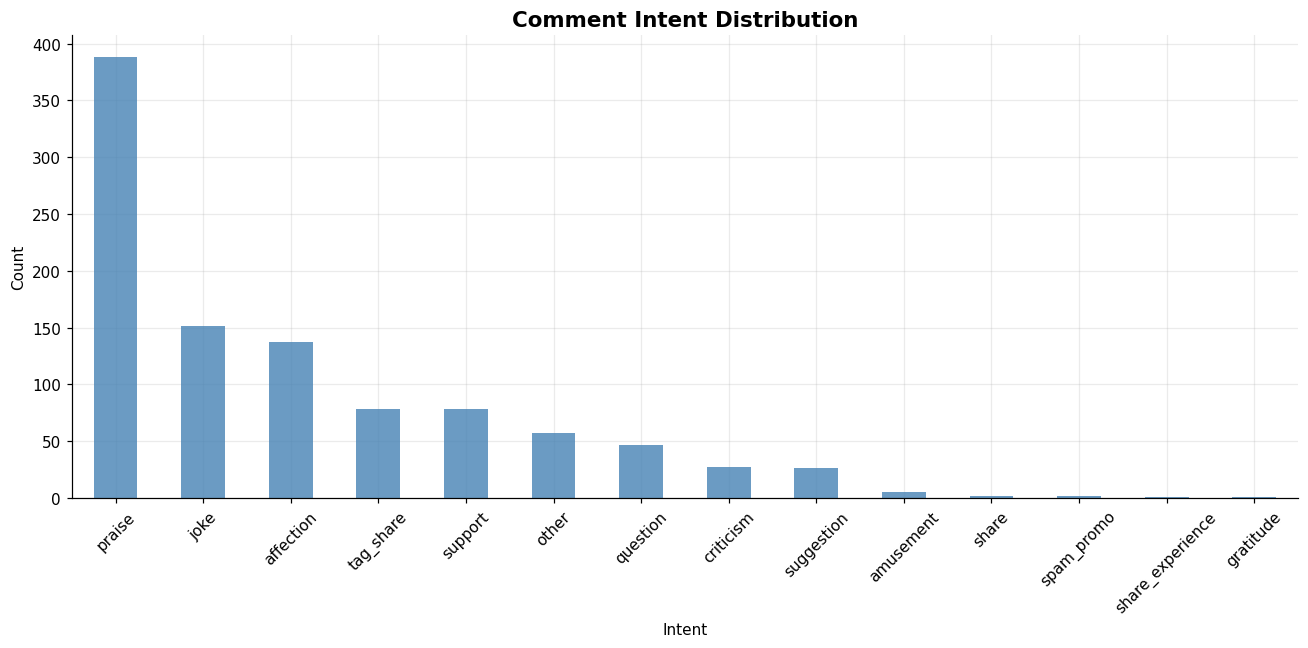


✅ Saved to 01_intent_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet(RESULTS_PATH)
n = len(df)

print("=== Intent Distribution ===")
intent_counts = df['intent'].value_counts()
for intent, count in intent_counts.items():
    pct = count / n * 100
    bar = '█' * int(pct / 2)
    print(f"  {intent:15} {count:7,}  ({pct:5.1f}%)  {bar}")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
intent_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Comment Intent Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Intent')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{LOCAL_DIR}/01_intent_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved to 01_intent_distribution.png")



=== Sentiment × Intent Cross-tabulation (counts) ===
intent     affection  amusement  criticism  gratitude  joke  other  praise  \
sentiment                                                                    
amused             0          0          0          0     5      0       0   
amusement          0          0          0          0     1      0       0   
mixed              0          0          3          0     4      8       2   
negative           0          0         22          0     2      6       0   
neutral            0          0          2          0    22     25       0   
positive         137          5          0          1   117     18     386   

intent     question  share  share_experience  spam_promo  suggestion  support  \
sentiment                                                                       
amused            1      0                 0           0           0        0   
amusement         0      0                 0           0           0        0 

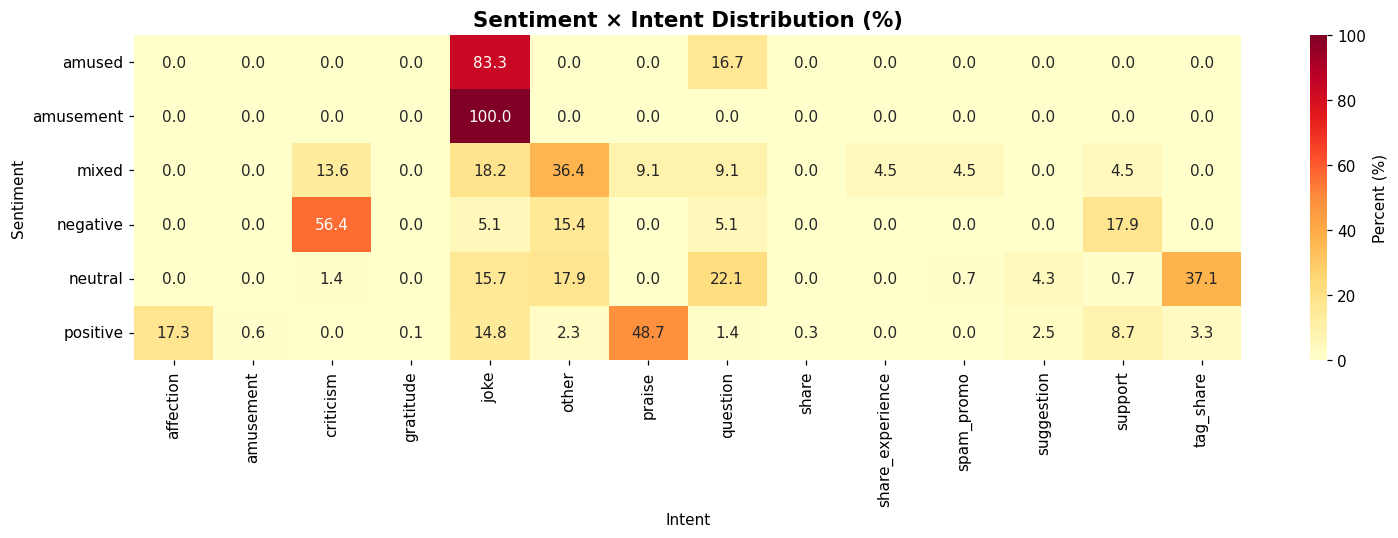


✅ Saved to 02_sentiment_intent_heatmap.png


In [ ]:
import numpy as np

df['sentiment'] = df['sentiment'].fillna('neutral')

crosstab = pd.crosstab(df['sentiment'], df['intent'], margins=False)
crosstab_pct = pd.crosstab(df['sentiment'], df['intent'], normalize='index') * 100

print("\n=== Sentiment × Intent Cross-tabulation (counts) ===")
print(crosstab)

print("\n=== By sentiment, % composition of intents ===")
print(crosstab_pct.round(1))

# Heatmap
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Percent (%)'})
ax.set_title('Sentiment × Intent Distribution (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Intent')
ax.set_ylabel('Sentiment')
plt.tight_layout()
plt.savefig(f'{LOCAL_DIR}/02_sentiment_intent_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved to 02_sentiment_intent_heatmap.png")


In [ ]:
print("=== Top 3 emotions per intent ===")
for intent in df['intent'].unique():
    subset = df[df['intent'] == intent]
    top_emotions = subset['emotion'].value_counts().head(3)
    emotions_str = ', '.join([f"{e} ({c})" for e, c in top_emotions.items()])
    print(f"  {intent:15}  →  {emotions_str}")


=== Top 3 emotions per intent ===
  praise           →  admiration (235), joy (62), amusement (50)
  joke             →  amusement (139), joy (10), annoyance (1)
  other            →  amusement (18), neutral (16), sadness (6)
  tag_share        →  neutral (43), amusement (22), joy (6)
  support          →  approval (19), joy (15), trust (9)
  criticism        →  disapproval (16), annoyance (3), disgust (3)
  affection        →  love (88), joy (20), affection (16)
  question         →  curiosity (30), amusement (4), neutral (4)
  suggestion       →  approval (6), curiosity (6), admiration (4)
  amusement        →  amusement (5)
  share_experience  →  sadness (1)
  share            →  joy (1), nostalgia (1)
  gratitude        →  gratitude (1)
  spam_promo       →  neutral (1), admiration (1)


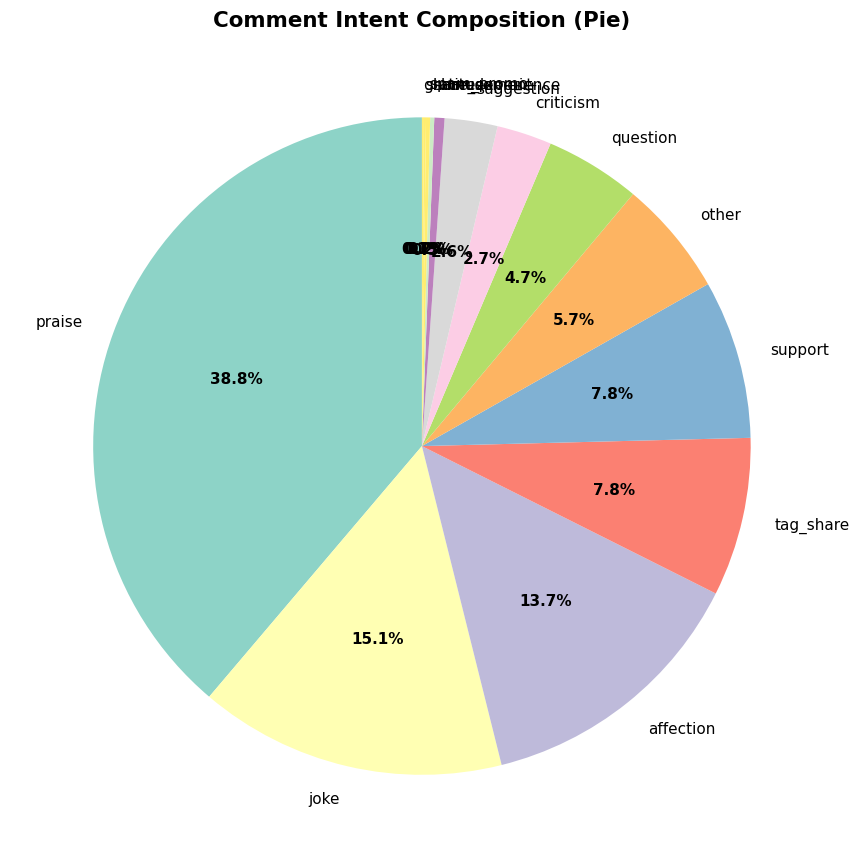


✅ Saved to 04_intent_pie_chart.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
intent_counts = df['intent'].value_counts()
colors = plt.cm.Set3(range(len(intent_counts)))
wedges, texts, autotexts = ax.pie(
    intent_counts.values,
    labels=intent_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
ax.set_title('Comment Intent Composition (Pie)', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
plt.tight_layout()
plt.savefig(f'{LOCAL_DIR}/04_intent_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved to 04_intent_pie_chart.png")


## Room Vibe — Polarity & Stance Alignment per Post

The **"vibe of the room"** under each post, two complementary ways:

* **Quantitative (authoritative)** — derived from every comment's sentiment on the post:
  `vibe_score` (overall polarity), `polarization` & `controversy` (are there opposing camps?),
  `stance_alignment` (−1 all against ⟷ +1 all for the creator), `consensus`, plus sarcasm / toxicity rates.
* **Narrative** — the model's own `room` read (vibe label, dominant stance, what splits the room,
  a 1–2 sentence summary), merged in from the largest analysed chunk of each post.

Writes a post-level table to `room_vibe_<platform>.parquet`.

In [ ]:
df.head()

,comment_id,media_id,media_context,sentiment,sentiment_score,emotion,intensity,sarcasm,toxicity,intent,target,lang,sentiment_cat,sarcasm_label,author_id,platform,text_length,word_count,emoji_count,unique_emoji_count,emoji_entropy,emoji_variety_ratio,emoji_per_word_ratio,url_count,mention_count,hashtag_count,exclamation_count,question_count,avg_word_length,has_numbers,has_links,timestamp,text
0,ig_comment_17952287248034678,17950533841037309,True,positive,0.8,admiration,high,False,none,praise,appearance,it,positive,not sarcastic,2312659669222593,instagram,18,2,0,0.0,0.000000,0.0,0.0,0,0,0,0,0,8.50,0,0,2018-06-07 12:33:23,CHIUDETE L’INDERNE
1,ig_comment_17936897722118456,17950533841037309,True,positive,0.9,admiration,high,False,none,praise,appearance,it,positive,not sarcastic,1267789398015947,instagram,14,2,2,2.0,0.693147,1.0,1.0,0,0,0,0,0,5.50,0,0,2018-06-07 12:29:45,No vabbè....🙈😍
2,ig_comment_17926181653139791,17950533841037309,True,positive,0.7,amusement,medium,False,none,joke,content_work,it,positive,not sarcastic,1470828354650935,instagram,10,1,0,0.0,0.000000,0.0,0.0,0,0,0,0,0,10.00,0,0,2018-06-07 12:27:07,HAHAHAHAHA
3,ig_comment_18063360790042629,17998026574211944,True,mixed,0.2,amusement,medium,False,none,other,product,it,positive,not sarcastic,807995049012907,instagram,128,25,0,0.0,0.000000,0.0,0.0,0,0,0,2,1,4.16,0,0,2019-05-12 14:38:01,Non sei la legittima erede al trono di Scozia? Ma io ti tolgo il “follow”! Ma chi ti segue più! Poraccitudine cioè io ci credevo
4,ig_comment_17962291675562237,17922360455296553,True,positive,0.6,amusement,medium,False,none,joke,content_work,it,positive,not sarcastic,1992551741638729,instagram,4,1,2,1.0,0.000000,0.5,2.0,0,0,0,0,0,4.00,0,0,2022-02-14 15:28:32,❤️❤️


In [ ]:
import numpy as np, pandas as pd, os

df = pd.read_parquet(RESULTS_PATH)
df["sentiment_score"] = pd.to_numeric(df["sentiment_score"], errors="coerce")
df["sentiment"] = df["sentiment"].fillna("neutral")

LOG2_3 = np.log2(3)
def _norm_entropy(pos, neg, neu):
    """Normalised Shannon entropy of the {pos,neg,neu} label mix -> 0 (united) .. 1 (max spread)."""
    p = np.array([pos, neg, neu]); p = p[p > 0]
    return float(-(p * np.log2(p)).sum()) / LOG2_3 if len(p) else 0.0

# ---- Quantitative room metrics per post (authoritative; over ALL of the post's comments) ----
rows = []
for mid, g in df.groupby("media_id"):
    n = len(g)
    s = g["sentiment_score"].dropna()
    lab = g["sentiment"]
    pos = float((lab == "positive").mean())
    neg = float((lab == "negative").mean())
    neu = float(max(0.0, 1 - pos - neg))
    rows.append({
        "media_id": mid, "n_comments": n,
        "media_context":    bool(g["media_context"].any()) if "media_context" in g else False,
        "vibe_score":       float(s.mean()) if len(s) else np.nan,          # overall polarity -1..1
        "dispersion":       float(s.std(ddof=0)) if len(s) > 1 else 0.0,    # spread of opinion
        "pos_frac": pos, "neg_frac": neg, "neu_frac": neu,
        "stance_alignment": float(np.sign(s).mean()) if len(s) else np.nan, # -1 all against .. +1 all for
        "polarization":     2 * min(pos, neg),                              # 0 one-sided .. 1 evenly split +/-
        "controversy":      4 * pos * neg,                                  # peaks when pos == neg
        "consensus":        1 - _norm_entropy(pos, neg, neu),               # 1 everyone same label
        "sarcasm_rate":     float(g["sarcasm"].fillna(False).mean()),
        "toxicity_rate":    float((g["toxicity"].fillna("none") != "none").mean()),
    })
room = pd.DataFrame(rows)
# Classify each post into united / divided / mixed based on controversy + consensus
def _room_state(r):
    if r["controversy"] >= 0.3: return "divided"
    if r["consensus"]  >= 0.6:  return "united"
    return "mixed"
room["room_state"] = room.apply(_room_state, axis=1)

# ---- Merge the LLM 'vibe of the room' narrative (largest chunk per post is most representative) ----
if os.path.exists(ROOM_LLM_PATH):
    rl = (pd.read_parquet(ROOM_LLM_PATH)
            .sort_values("n_comments_chunk", ascending=False)
            .drop_duplicates("media_id"))
    keep = ["media_id", "llm_vibe", "dominant_stance", "split_axis", "room_summary",
            "llm_consensus", "llm_alignment", "llm_controversy"]
    room = room.merge(rl[[c for c in keep if c in rl.columns]], on="media_id", how="left")

room.to_parquet(ROOM_PATH, index=False)
print(f"✅ Room vibe for {len(room):,} posts -> {ROOM_PATH}\n")

view = room[room["n_comments"] >= 5].copy()
show = [c for c in ["media_id", "n_comments", "vibe_score", "polarization", "controversy",
                    "stance_alignment", "llm_vibe", "room_summary"] if c in view.columns]
print("=== Most DIVIDED / controversial rooms (n>=5) ===")
print(view.sort_values("controversy", ascending=False).head(8)[show].to_string(index=False))
print("\n=== Most UNITED / aligned rooms (n>=5) ===")
print(view.sort_values(["consensus", "n_comments"], ascending=[False, False]).head(8)[show].to_string(index=False))
print("\n--- Overall ---")
print(f"  mean vibe_score   : {room['vibe_score'].mean():+.3f}   (room-level polarity)")
print(f"  mean polarization : {room['polarization'].mean():.3f}")
print(f"  mean consensus    : {room['consensus'].mean():.3f}")
if "llm_vibe" in room.columns:
    print("\n  LLM room-vibe distribution:")
    for k, v in room["llm_vibe"].value_counts().head(10).items():
        print(f"    {str(k):14} {v:5,}")

✅ Room vibe for 561 posts -> outputs/room_vibe_instagram.parquet

=== Most DIVIDED / controversial rooms (n>=5) ===
         media_id  n_comments  vibe_score  polarization  controversy  stance_alignment     llm_vibe                                                                                                                                                                                                                                                                                                                                                           room_summary
18063792412351257           5   -0.100000           0.4         0.32         -0.400000   supportive The room is largely supportive, with commenters relating to the creator's feeling of missing out on holidays due to work. Many express that their own situation is even more challenging, creating a shared sense of 'we're all in this together' but with a slightly negative undertone due to the shared predicament. One comment p

## Visualizations

Informative plots over the LLM's numeric **and** categorical outputs. Each cell saves a PNG to
`outputs/figs/` and displays inline. Run the **setup** cell first.

1. **Overview** — score distribution + every categorical proportion (sentiment / sarcasm / emotion / intent / toxicity).
2. **Cross-validation** — do the categorical labels agree with the numeric score? Box-by-label, categorical
   proportions vs. score-derived proportions, and an agreement matrix (this is the cross-check requested).
3. **Over time** — polarity (mean score) over time + a 100% stacked sentiment composition.
4. **Emotion & features** — mean score per emotion, feature↔score correlations, score by toxicity.
5. **Room level** — the post "vibe map" (polarity × controversy), and the LLM's room numbers vs. the ones
   computed from per-comment sentiment.

loaded 1,000 comments | 561 posts | 2016-08-20 → 2026-03-19
  saved outputs/figs/01_overview.png


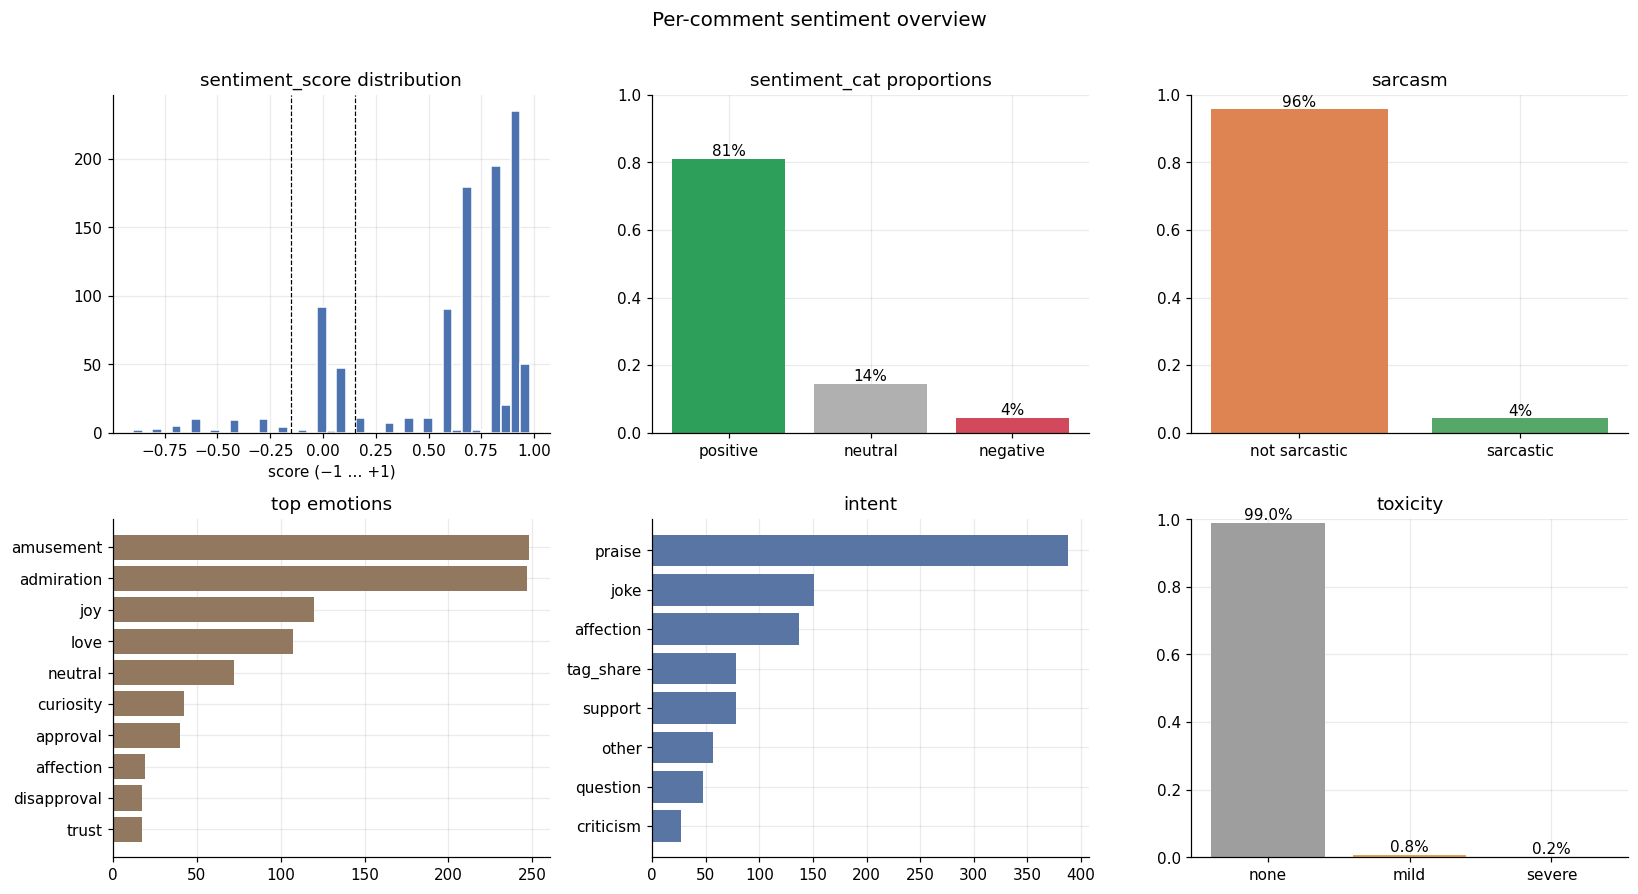

In [ ]:
# === Visualization setup (RUN FIRST) — loads the tables, palette & helpers used by the plots below ===
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
FIG_DIR = f"{LOCAL_DIR}/figs"; os.makedirs(FIG_DIR, exist_ok=True)
POS_C, NEU_C, NEG_C = "#2e9e5b", "#b0b0b0", "#d1495b"            # green / grey / red
CAT_COLORS = {"positive": POS_C, "neutral": NEU_C, "negative": NEG_C}
band = globals().get("NEUTRAL_BAND", 0.15)
def _save(fig, name):
    p = f"{FIG_DIR}/{name}.png"; fig.savefig(p, bbox_inches="tight"); print("  saved", p)

sent = pd.read_parquet(RESULTS_PATH)
sent["sentiment_score"] = pd.to_numeric(sent["sentiment_score"], errors="coerce")
if "timestamp" in sent.columns:
    sent["timestamp"] = pd.to_datetime(sent["timestamp"], errors="coerce", utc=True)
room = pd.read_parquet(ROOM_PATH) if os.path.exists(ROOM_PATH) else None
if room is not None and "room_state" not in room.columns:
    def _rs(r):
        if r["controversy"] >= 0.3: return "divided"
        if r["consensus"]  >= 0.6:  return "united"
        return "mixed"
    room["room_state"] = room.apply(_rs, axis=1)
if room is not None and "sentiment_cat" not in room.columns:
    _b = band
    def _sc(r):
        s = str(r.get("sentiment","")).lower()
        if s in ("positive","negative","neutral"): return s
        v = r.get("vibe_score", float("nan"))
        try: v = float(v)
        except: return "neutral"
        return "positive" if v > _b else "negative" if v < -_b else "neutral"
    room["sentiment_cat"] = room.apply(_sc, axis=1)
_msg = f"loaded {len(sent):,} comments"
if room is not None: _msg += f" | {len(room):,} posts"
if "timestamp" in sent.columns and sent["timestamp"].notna().any():
    _msg += f" | {sent['timestamp'].min():%Y-%m-%d} → {sent['timestamp'].max():%Y-%m-%d}"
print(_msg)

# ---- Per-comment overview: the numeric distribution + every categorical proportion ----
n = len(sent)
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# (a) numeric: sentiment_score distribution, with the neutral band marked
ax[0, 0].hist(sent["sentiment_score"].dropna(), bins=41, color="#4c72b0", edgecolor="white")
for b in (-band, band): ax[0, 0].axvline(b, color="k", ls="--", lw=.8)
ax[0, 0].set_title("sentiment_score distribution"); ax[0, 0].set_xlabel("score (−1 … +1)")

# (b) categorical: sentiment_cat proportions
vc = sent["sentiment_cat"].value_counts(normalize=True).reindex(["positive", "neutral", "negative"]).fillna(0)
ax[0, 1].bar(vc.index, vc.values, color=[CAT_COLORS[c] for c in vc.index])
for i, v in enumerate(vc.values): ax[0, 1].text(i, v, f"{v:.0%}", ha="center", va="bottom")
ax[0, 1].set_ylim(0, 1); ax[0, 1].set_title("sentiment_cat proportions")

# (c) categorical: sarcasm
vs = sent["sarcasm_label"].value_counts(normalize=True)
ax[0, 2].bar(vs.index, vs.values, color=["#dd8452", "#55a868"][:len(vs)])
for i, v in enumerate(vs.values): ax[0, 2].text(i, v, f"{v:.0%}", ha="center", va="bottom")
ax[0, 2].set_ylim(0, 1); ax[0, 2].set_title("sarcasm")

# (d) categorical: top emotions
em = sent["emotion"].value_counts().head(10)[::-1]
ax[1, 0].barh(em.index, em.values, color="#937860"); ax[1, 0].set_title("top emotions")

# (e) categorical: intent
it = sent["intent"].value_counts().head(8)[::-1]
ax[1, 1].barh(it.index, it.values, color="#5975a4"); ax[1, 1].set_title("intent")

# (f) categorical: toxicity
tx = sent["toxicity"].value_counts(normalize=True).reindex(["none", "mild", "severe"]).fillna(0)
ax[1, 2].bar(tx.index, tx.values, color=["#9e9e9e", "#e0a458", "#c44e52"])
for i, v in enumerate(tx.values): ax[1, 2].text(i, v, f"{v:.1%}", ha="center", va="bottom")
ax[1, 2].set_ylim(0, 1); ax[1, 2].set_title("toxicity")

fig.suptitle("Per-comment sentiment overview", fontsize=13, y=1.01)
fig.tight_layout(); _save(fig, "01_overview"); plt.show()

  saved outputs/figs/02_crossval.png


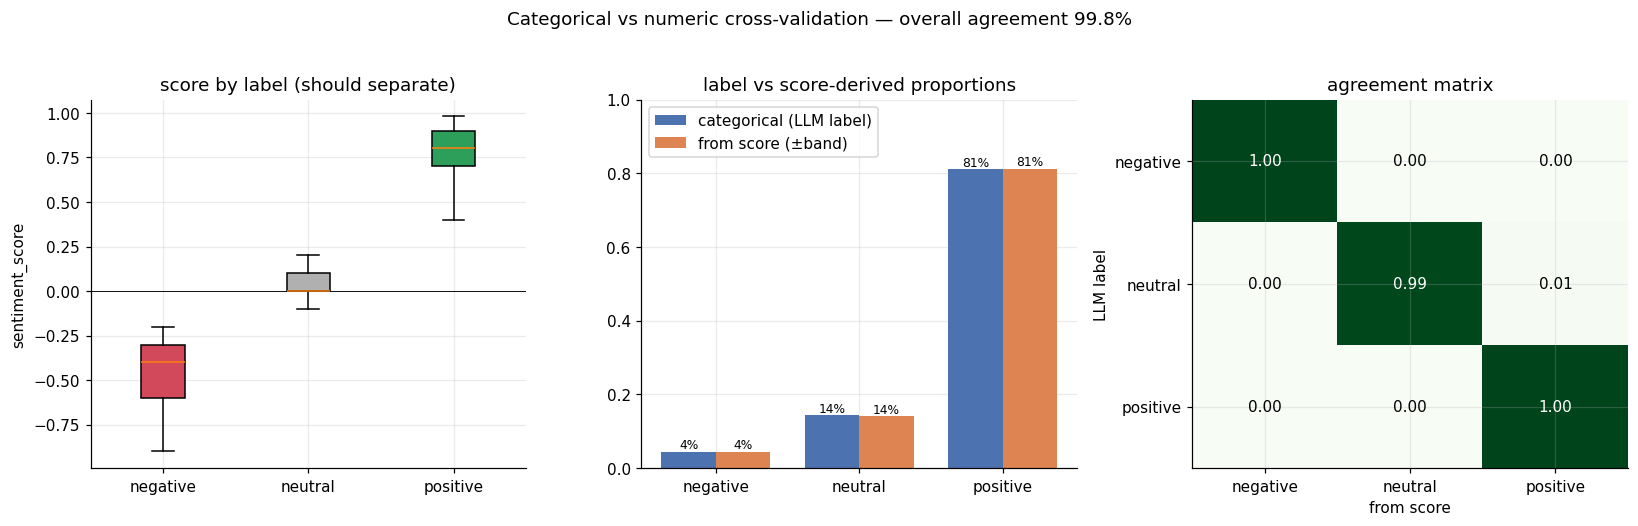

label↔score agreement: 99.8%  |  mean score by label: {'negative': -0.49, 'neutral': 0.03, 'positive': 0.77}


In [ ]:
# === Cross-validation: do the categorical labels agree with the numeric score? ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
order = ["negative", "neutral", "positive"]
def _s2c(x):
    if pd.isna(x): return "neutral"
    return "positive" if x > band else "negative" if x < -band else "neutral"
num_cat  = sent["sentiment_score"].map(_s2c)                       # category implied by the number
agree    = float((sent["sentiment_cat"] == num_cat).mean())
cat_prop = sent["sentiment_cat"].value_counts(normalize=True).reindex(order).fillna(0)
num_prop = num_cat.value_counts(normalize=True).reindex(order).fillna(0)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))

# (a) score distribution per categorical label — should separate negative < neutral < positive
data = [sent.loc[sent["sentiment_cat"] == c, "sentiment_score"].dropna().values for c in order]
bp = ax[0].boxplot(data, showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], order): patch.set_facecolor(CAT_COLORS[c])
ax[0].set_xticks(range(1, 4)); ax[0].set_xticklabels(order)
ax[0].axhline(0, color="k", lw=.6); ax[0].set_ylabel("sentiment_score"); ax[0].set_title("score by label (should separate)")

# (b) categorical proportions vs proportions derived from the score — the cross-check you asked for
x = np.arange(3); w = 0.38
ax[1].bar(x - w/2, cat_prop.values, w, label="categorical (LLM label)", color="#4c72b0")
ax[1].bar(x + w/2, num_prop.values, w, label="from score (±band)",      color="#dd8452")
for i in range(3):
    ax[1].text(i - w/2, cat_prop.values[i], f"{cat_prop.values[i]:.0%}", ha="center", va="bottom", fontsize=8)
    ax[1].text(i + w/2, num_prop.values[i], f"{num_prop.values[i]:.0%}", ha="center", va="bottom", fontsize=8)
ax[1].set_xticks(x); ax[1].set_xticklabels(order); ax[1].set_ylim(0, 1)
ax[1].legend(); ax[1].set_title("label vs score-derived proportions")

# (c) agreement matrix (row-normalised) — mass on the diagonal = labels match the numbers
ct = (pd.crosstab(sent["sentiment_cat"], num_cat, normalize="index")
        .reindex(index=order, columns=order).fillna(0))
ax[2].imshow(ct.values, cmap="Greens", vmin=0, vmax=1, aspect="auto")
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(order); ax[2].set_yticks(range(3)); ax[2].set_yticklabels(order)
ax[2].set_xlabel("from score"); ax[2].set_ylabel("LLM label")
for i in range(3):
    for j in range(3):
        ax[2].text(j, i, f"{ct.values[i, j]:.2f}", ha="center", va="center",
                   color="white" if ct.values[i, j] > .6 else "black")
ax[2].set_title("agreement matrix")

fig.suptitle(f"Categorical vs numeric cross-validation — overall agreement {agree:.1%}", y=1.03)
fig.tight_layout(); _save(fig, "02_crossval"); plt.show()
print(f"label↔score agreement: {agree:.1%}  |  mean score by label:",
      {c: round(float(sent.loc[sent['sentiment_cat'] == c, 'sentiment_score'].mean()), 2) for c in order})

  saved outputs/figs/03_timeseries.png


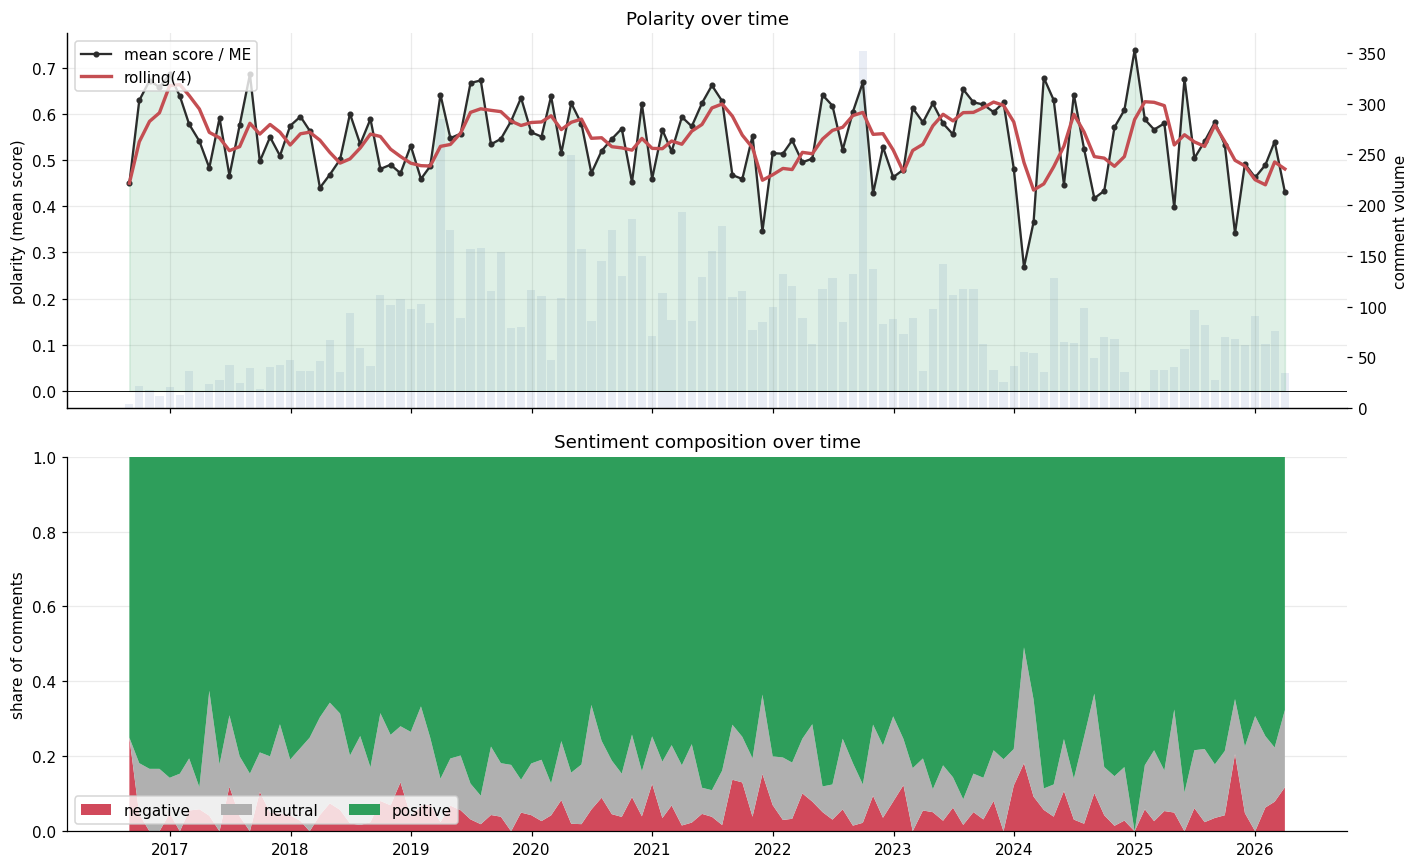

resample freq: ME | periods: 116 | span: 3498 days


In [ ]:
# === Polarity over time + sentiment composition over time ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
if "timestamp" not in sent.columns or sent["timestamp"].notna().sum() == 0:
    print("No usable timestamps — skipping time series.")
else:
    ts = sent.dropna(subset=["timestamp"]).set_index("timestamp").sort_index()
    span_days = (ts.index.max() - ts.index.min()).days
    freq = "D" if span_days <= 60 else "W" if span_days <= 730 else "ME"   # adaptive bucket
    width = {"D": 0.8, "W": 5, "ME": 25}[freq]

    pol = ts["sentiment_score"].resample(freq).mean()
    vol = ts["sentiment_score"].resample(freq).size()
    comp = (ts.assign(_one=1).groupby([pd.Grouper(freq=freq), "sentiment_cat"])["_one"].sum()
              .unstack("sentiment_cat").reindex(columns=["negative", "neutral", "positive"]).fillna(0))
    comp_prop = comp.div(comp.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    # (top) mean polarity + rolling trend, with comment volume behind it
    axv = ax[0].twinx(); axv.bar(vol.index, vol.values, width=width, alpha=.12, color="#4c72b0"); axv.grid(False)
    axv.set_ylabel("comment volume")
    ax[0].axhline(0, color="k", lw=.6)
    ax[0].plot(pol.index, pol.values, color="#2c2c2c", lw=1.5, marker="o", ms=3, label=f"mean score / {freq}")
    if pol.notna().sum() >= 5:
        ax[0].plot(pol.index, pol.rolling(4, min_periods=1).mean().values, color="#c44e52", lw=2.2, label="rolling(4)")
    ax[0].fill_between(pol.index, pol.values, 0, where=pol.values >= 0, color=POS_C, alpha=.15, interpolate=True)
    ax[0].fill_between(pol.index, pol.values, 0, where=pol.values < 0, color=NEG_C, alpha=.15, interpolate=True)
    ax[0].set_ylabel("polarity (mean score)"); ax[0].set_title("Polarity over time"); ax[0].set_zorder(axv.get_zorder() + 1)
    ax[0].patch.set_visible(False); ax[0].legend(loc="upper left")

    # (bottom) 100% stacked composition of the categorical sentiment
    ax[1].stackplot(comp_prop.index, comp_prop["negative"], comp_prop["neutral"], comp_prop["positive"],
                    colors=[NEG_C, NEU_C, POS_C], labels=["negative", "neutral", "positive"])
    ax[1].set_ylim(0, 1); ax[1].set_ylabel("share of comments")
    ax[1].set_title("Sentiment composition over time"); ax[1].legend(loc="lower left", ncol=3)
    fig.tight_layout(); _save(fig, "03_timeseries"); plt.show()
    print(f"resample freq: {freq} | periods: {len(pol)} | span: {span_days} days")

  saved outputs/figs/04_emotion_features.png


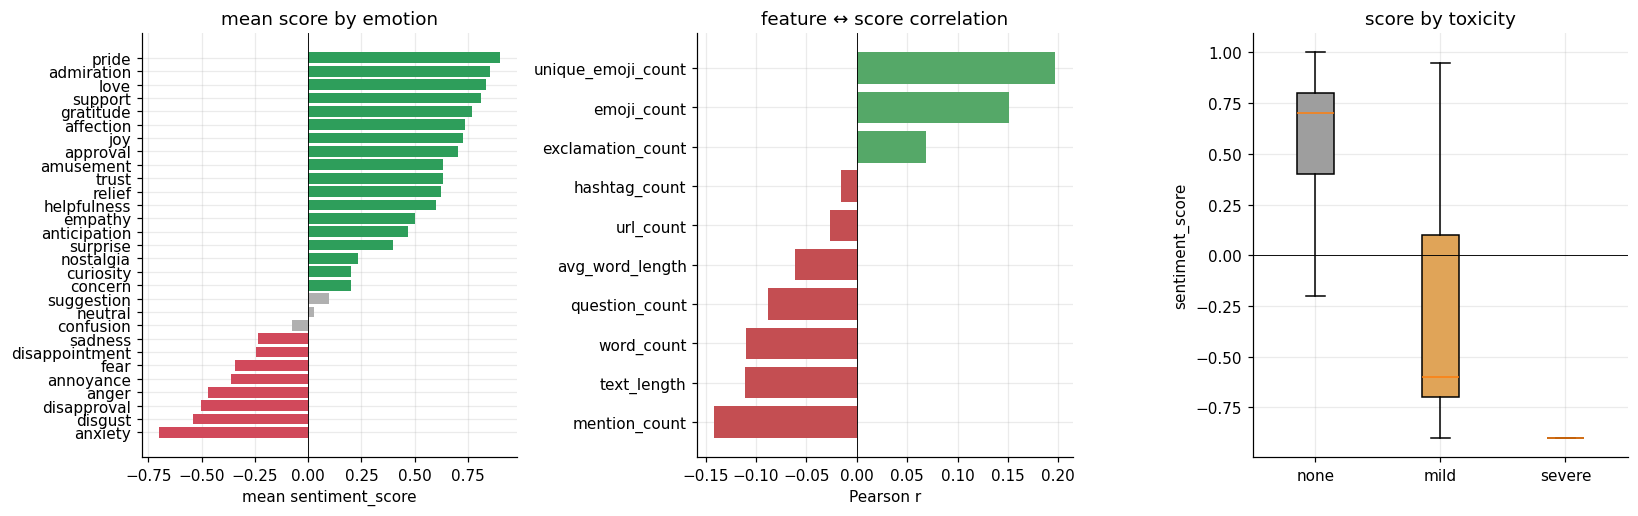

In [ ]:
# === Emotion validity + which numeric features track sentiment + toxicity check ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))

# (a) mean score by emotion — does each categorical emotion sit where its polarity should?
em = sent.groupby("emotion")["sentiment_score"].mean().sort_values()
ecols = [POS_C if v > band else NEG_C if v < -band else NEU_C for v in em.values]
ax[0].barh(em.index, em.values, color=ecols); ax[0].axvline(0, color="k", lw=.6)
ax[0].set_title("mean score by emotion"); ax[0].set_xlabel("mean sentiment_score")

# (b) correlation of engagement features with the sentiment score
featcols = [c for c in ["word_count", "text_length", "avg_word_length", "emoji_count", "unique_emoji_count",
                        "exclamation_count", "question_count", "mention_count", "hashtag_count", "url_count"]
            if c in sent.columns]
if featcols:
    cor = (sent[featcols + ["sentiment_score"]].apply(pd.to_numeric, errors="coerce")
           .corr()["sentiment_score"].drop("sentiment_score").sort_values())
    ax[1].barh(cor.index, cor.values, color=["#c44e52" if v < 0 else "#55a868" for v in cor.values])
    ax[1].axvline(0, color="k", lw=.6); ax[1].set_xlabel("Pearson r")
    ax[1].set_title("feature ↔ score correlation")
else:
    ax[1].axis("off"); ax[1].set_title("no numeric features")

# (c) score by toxicity — validates the toxicity label against polarity
torder = [t for t in ["none", "mild", "severe"] if (sent["toxicity"] == t).any()]
data = [sent.loc[sent["toxicity"] == t, "sentiment_score"].dropna().values for t in torder]
bp = ax[2].boxplot(data, showfliers=False, patch_artist=True)
for p, t in zip(bp["boxes"], torder):
    p.set_facecolor({"none": "#9e9e9e", "mild": "#e0a458", "severe": "#c44e52"}[t])
ax[2].set_xticks(range(1, len(torder) + 1)); ax[2].set_xticklabels(torder)
ax[2].axhline(0, color="k", lw=.6); ax[2].set_ylabel("sentiment_score"); ax[2].set_title("score by toxicity")

fig.tight_layout(); _save(fig, "04_emotion_features"); plt.show()

  saved outputs/figs/04b_targets.png


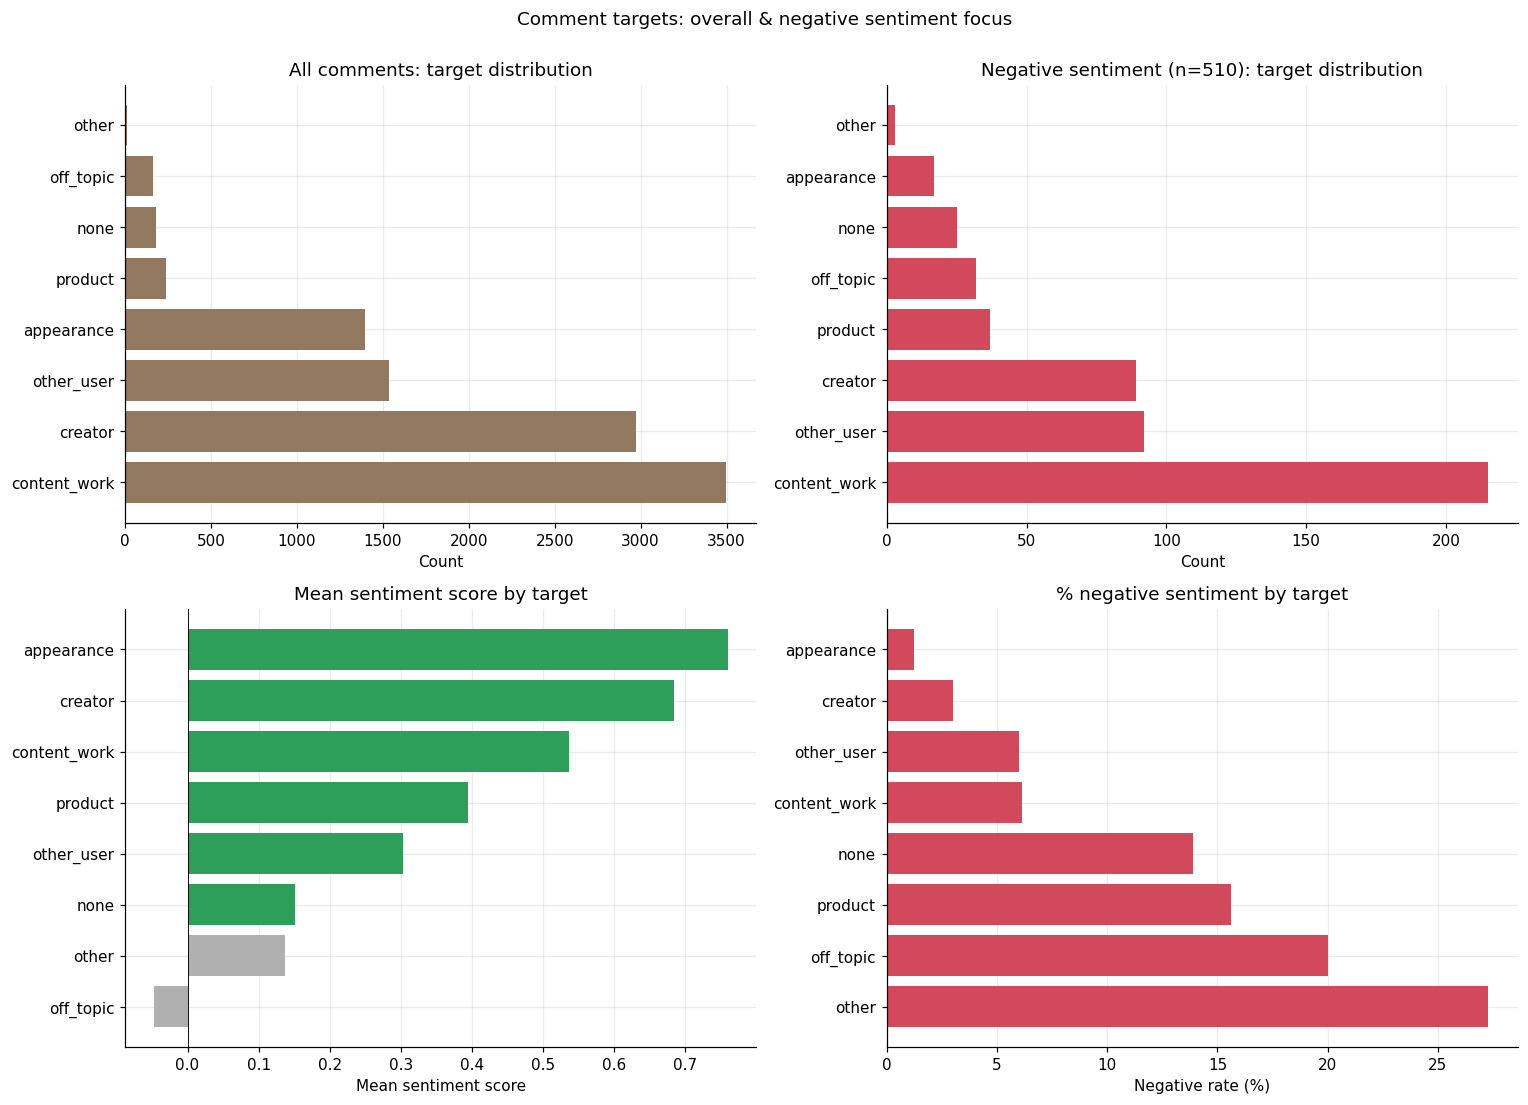

Target breakdown for negative sentiment (n=510):
target
content_work    215
other_user       92
creator          89
product          37
off_topic        32
none             25
appearance       17
other             3
Name: count, dtype: int64
Negative rate by target:
other           27.3
off_topic       20.0
product         15.6
none            13.9
content_work     6.1
other_user       6.0
creator          3.0
appearance       1.2
dtype: float64


In [ ]:
# === Comment targets breakdown, especially negative sentiment ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# (a) Target distribution across all comments
tgt = sent["target"].value_counts()
ax[0, 0].barh(tgt.index, tgt.values, color="#937860")
ax[0, 0].set_xlabel("Count"); ax[0, 0].set_title("All comments: target distribution")

# (b) Target distribution for NEGATIVE sentiment only
neg_df = sent[sent["sentiment_score"] < -band]
tgt_neg = neg_df["target"].value_counts()
ax[0, 1].barh(tgt_neg.index, tgt_neg.values, color="#d1495b")
ax[0, 1].set_xlabel("Count"); ax[0, 1].set_title(f"Negative sentiment (n={len(neg_df)}): target distribution")

# (c) Mean sentiment score by target
mean_by_tgt = sent.groupby("target")["sentiment_score"].agg(["mean", "count"]).sort_values("mean")
colors = [POS_C if v > band else NEG_C if v < -band else NEU_C for v in mean_by_tgt["mean"].values]
ax[1, 0].barh(mean_by_tgt.index, mean_by_tgt["mean"].values, color=colors)
ax[1, 0].axvline(0, color="k", lw=0.6); ax[1, 0].set_xlabel("Mean sentiment score")
ax[1, 0].set_title("Mean sentiment score by target")

# (d) Negative rate by target (% of comments with negative sentiment)
neg_rates = {}
for tgt_val in sent["target"].unique():
    subset = sent[sent["target"] == tgt_val]
    neg_rate = (subset["sentiment_score"] < -band).sum() / len(subset) if len(subset) > 0 else 0
    neg_rates[tgt_val] = neg_rate
neg_rates_df = pd.Series(neg_rates).sort_values(ascending=False)
ax[1, 1].barh(neg_rates_df.index, neg_rates_df.values * 100, color="#d1495b")
ax[1, 1].set_xlabel("Negative rate (%)"); ax[1, 1].set_title("% negative sentiment by target")

fig.suptitle("Comment targets: overall & negative sentiment focus", y=1.00)
fig.tight_layout(); _save(fig, "04b_targets"); plt.show()

print(f"Target breakdown for negative sentiment (n={len(neg_df)}):"); print(tgt_neg)
print(f"Negative rate by target:"); print((neg_rates_df * 100).round(1))


  saved outputs/figs/05_room.png


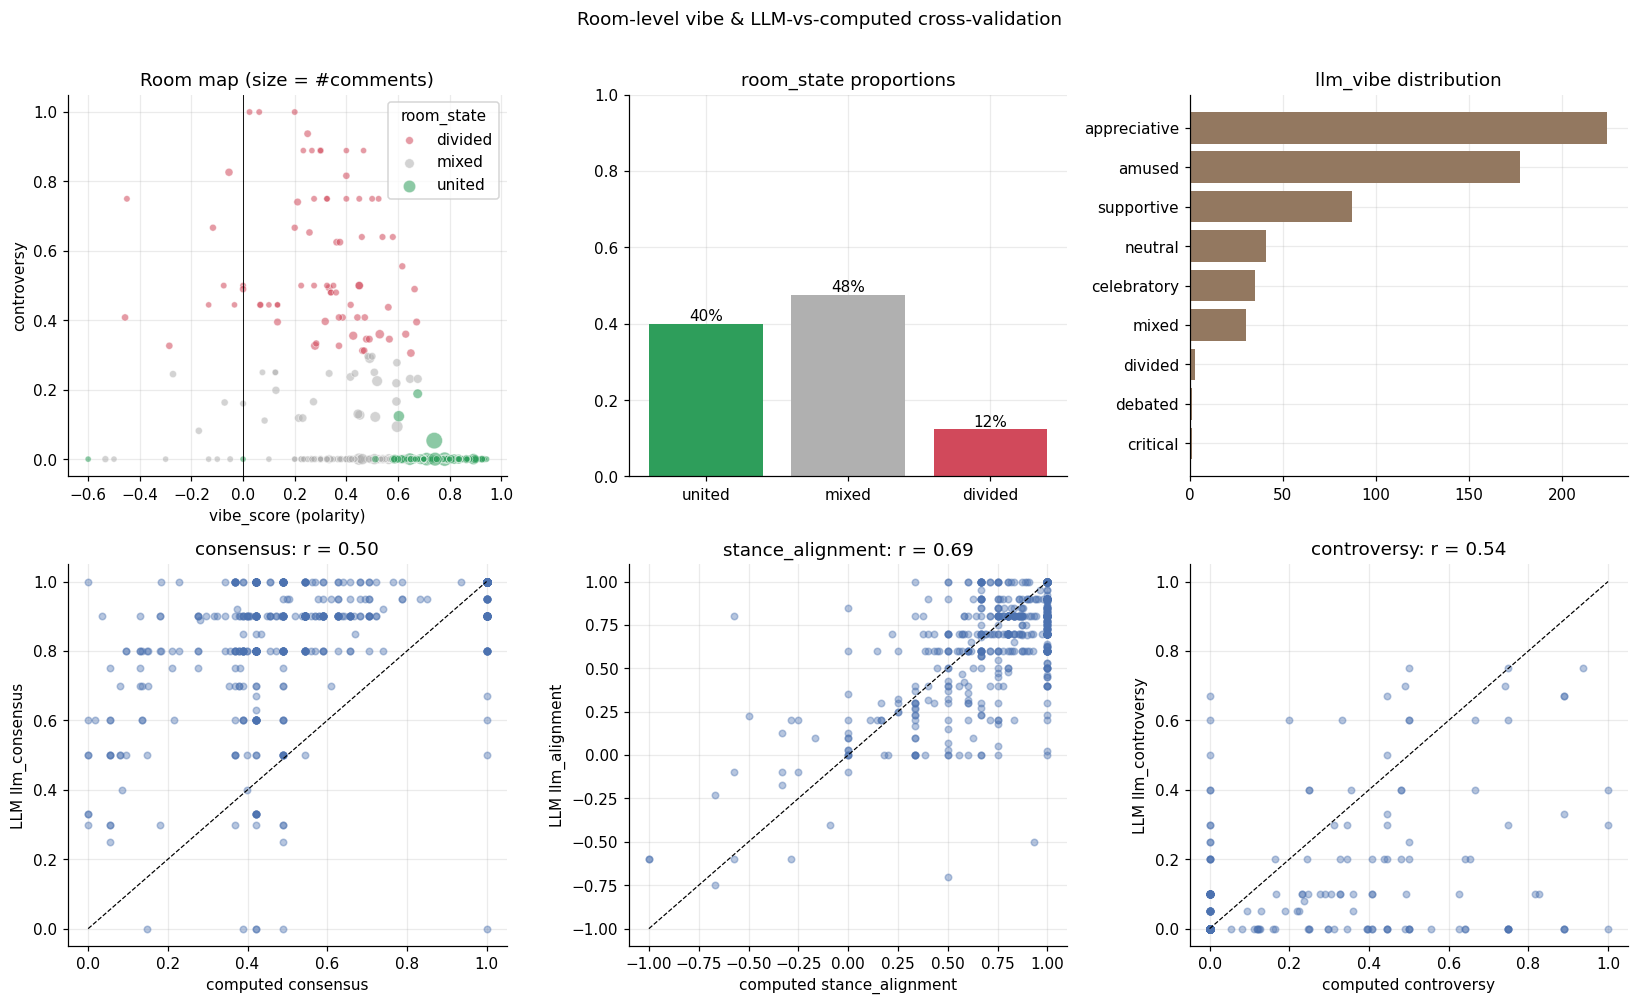

In [ ]:
# === Room-level: the 'vibe map' + cross-validation of LLM room numbers vs the computed ones ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
if room is None or not len(room):
    print("No room_vibe table in memory — run the Room Vibe cell first.")
else:
    if "room_state" not in room.columns:
        def _rs(r):
            if r["controversy"] >= 0.3: return "divided"
            if r["consensus"]  >= 0.6:  return "united"
            return "mixed"
        room["room_state"] = room.apply(_rs, axis=1)
    rv = room[room["n_comments"] >= 3].copy()
    STATE_C = {"united": POS_C, "mixed": NEU_C, "divided": NEG_C}
    fig, ax = plt.subplots(2, 3, figsize=(15, 9))

    # (a) the vibe map: polarity vs controversy, size = #comments, colour = room_state
    for st, gdf in rv.groupby("room_state"):
        ax[0, 0].scatter(gdf["vibe_score"], gdf["controversy"],
                         s=gdf["n_comments"].clip(upper=200) * 1.4 + 12,
                         c=STATE_C.get(st, "#777"), alpha=.55, edgecolor="white", linewidth=.5, label=st)
    ax[0, 0].axvline(0, color="k", lw=.6)
    ax[0, 0].set_xlabel("vibe_score (polarity)"); ax[0, 0].set_ylabel("controversy")
    ax[0, 0].set_title("Room map (size = #comments)"); ax[0, 0].legend(title="room_state")

    # (b) room_state proportions
    rs = rv["room_state"].value_counts(normalize=True).reindex(["united", "mixed", "divided"]).fillna(0)
    ax[0, 1].bar(rs.index, rs.values, color=[STATE_C[s] for s in rs.index])
    for i, v in enumerate(rs.values): ax[0, 1].text(i, v, f"{v:.0%}", ha="center", va="bottom")
    ax[0, 1].set_ylim(0, 1); ax[0, 1].set_title("room_state proportions")

    # (c) llm_vibe distribution
    if "llm_vibe" in rv.columns and rv["llm_vibe"].notna().any():
        lv = rv["llm_vibe"].value_counts().head(10)[::-1]
        ax[0, 2].barh(lv.index, lv.values, color="#937860"); ax[0, 2].set_title("llm_vibe distribution")
    else:
        ax[0, 2].axis("off"); ax[0, 2].set_title("llm_vibe (n/a)")

    # (d-f) LLM self-reported room metric vs the metric computed from per-comment sentiment
    pairs = [("consensus", "llm_consensus"), ("stance_alignment", "llm_alignment"), ("controversy", "llm_controversy")]
    for k, (dvar, lvar) in enumerate(pairs):
        a = ax[1, k]
        if dvar in rv.columns and lvar in rv.columns and rv[lvar].notna().any():
            d = rv[[dvar, lvar]].apply(pd.to_numeric, errors="coerce").dropna()
            a.scatter(d[dvar], d[lvar], s=18, alpha=.4, color="#4c72b0")
            if len(d):
                lo = float(min(d[dvar].min(), d[lvar].min())); hi = float(max(d[dvar].max(), d[lvar].max()))
                a.plot([lo, hi], [lo, hi], "k--", lw=.8)
            r = d[dvar].corr(d[lvar]) if len(d) > 2 else float("nan")
            a.set_xlabel(f"computed {dvar}"); a.set_ylabel(f"LLM {lvar}"); a.set_title(f"{dvar}: r = {r:.2f}")
        else:
            a.axis("off"); a.set_title(f"{lvar} (n/a)")
    fig.suptitle("Room-level vibe & LLM-vs-computed cross-validation", y=1.01)
    fig.tight_layout(); _save(fig, "05_room"); plt.show()

In [ ]:
df[(df.target == "creator") & (df.sentiment == "negative")][["text", "sentiment_score", "emotion", "intent"]].text.iloc[4]


'Tipica risposta di donna che ha passato i 35 e rosica, un po’ stile “Rolex per un Casio”. Che bisogno c’è di rosicare che magari domani ci svegliamo tutti vestiti eleganti?'

## Ad / Promotion Reception

A separate read on **sponsored / promotional posts** — are the promos received well by the audience?

**Detection (no extra LLM cost)** uses the real post metadata in `ig_multimodal_final`:
the official `is_paid_partnership` flag, `sponsor_usernames`, product tags, plus a caption-disclosure
regex (`#adv`, `sponsorizzato`, `in collaborazione`, `gifted`, `codice sconto`, `giveaway`, …).
~9% of posts are promotional.

**Reception** reuses the per-comment sentiment: it compares promo vs. the rest of the feed
(mean score, %positive/%negative, sarcasm, criticism, toxicity), zooms into `target=="product"`
comments for the most direct product read, and scores each promo post
(`well_received` / `mixed` / `poorly_received`) → `promo_reception_<platform>.parquet`.

Run the **detection** cell first.

In [ ]:
# === Ad / Promotion detection (RUN FIRST in this section) — flags promo posts from real metadata ===
import os, re, numpy as np, pandas as pd

# reuse the viz palette/helpers if present, else define (keeps this section self-contained)
POS_C = globals().get("POS_C", "#2e9e5b"); NEU_C = globals().get("NEU_C", "#b0b0b0"); NEG_C = globals().get("NEG_C", "#d1495b")
band = globals().get("NEUTRAL_BAND", 0.15)
FIG_DIR = globals().get("FIG_DIR", f"{LOCAL_DIR}/figs"); os.makedirs(FIG_DIR, exist_ok=True)
def _psave(fig, name):
    p = f"{FIG_DIR}/{name}.png"; fig.savefig(p, bbox_inches="tight"); print("  saved", p)
def _norm_id(x):
    s = str(x); return s[:-2] if s.endswith(".0") else s
def _has(v):
    return hasattr(v, "__len__") and not isinstance(v, str) and len(v) > 0

# 1) per-comment sentiment (read from disk -> independent of the viz section)
ps = pd.read_parquet(RESULTS_PATH)
ps["sentiment_score"] = pd.to_numeric(ps["sentiment_score"], errors="coerce")
ps["media_id_n"] = ps["media_id"].map(_norm_id)

# 2) post-level ad signals from the media index: official flags + caption disclosure
_cols = ["media_id", "shortcode", "caption", "is_paid_partnership", "sponsor_usernames",
         "n_product_tags", "tagged_usernames", "permalink", "like_count", "comments_count"]
mi = pd.read_parquet(MEDIA_INDEX_PATH, columns=_cols)
mi["media_id_n"] = mi["media_id"].map(_norm_id)
cap = mi["caption"].fillna("").str.lower()
AD_RE = re.compile(r"(?:#adv|\badv\b|#ad\b|sponsor|sponsorizzat|pubblicit|in collaborazione|"
                   r"paid partnership|#gifted|\bgifted\b|codice sconto|giveaway|#suppliedby)")
mi["paid"]     = mi["is_paid_partnership"].fillna(False)
mi["has_spon"] = mi["sponsor_usernames"].apply(_has)
mi["has_prod"] = mi["n_product_tags"].fillna(0) > 0
mi["kw_ad"]    = cap.str.contains(AD_RE)
mi["is_promo"] = mi["paid"] | mi["has_spon"] | mi["has_prod"] | mi["kw_ad"]
def _ptype(r):
    if r["paid"]:     return "paid_partnership"
    if r["has_spon"]: return "sponsor_tag"
    if r["has_prod"]: return "product_tag"
    if r["kw_ad"]:    return "caption_disclosure"
    return "none"
mi["promo_type"]   = mi.apply(_ptype, axis=1)
mi["sponsor"]      = mi["sponsor_usernames"].apply(lambda v: ", ".join(v) if _has(v) else "")
mi["caption_snip"] = mi["caption"].fillna("").str.slice(0, 120)

# 3) flag every analysed comment by its post
ps["is_promo"]   = ps["media_id_n"].map(dict(zip(mi["media_id_n"], mi["is_promo"]))).fillna(False)
ps["promo_type"] = ps["media_id_n"].map(dict(zip(mi["media_id_n"], mi["promo_type"]))).fillna("none")
ps["sponsor"]    = ps["media_id_n"].map(dict(zip(mi["media_id_n"], mi["sponsor"]))).fillna("")

promo_posts = sorted(set(ps.loc[ps["is_promo"], "media_id_n"]))
print(f"Promo posts in dataset       : {int(mi['is_promo'].sum()):,} / {len(mi):,} ({mi['is_promo'].mean():.1%})")
print(f"   by type: {mi.loc[mi['is_promo'], 'promo_type'].value_counts().to_dict()}")
print(f"Promo posts WITH analysed comments: {len(promo_posts):,}")
print(f"Comments under promo posts   : {int(ps['is_promo'].sum()):,} / {len(ps):,} ({ps['is_promo'].mean():.1%})")
if ps["is_promo"].sum() == 0:
    print("\n⚠️  None of the analysed comments fall on promo posts — raise MAX_COMMENTS (or keep "
          "PRIORITIZE_MEDIA_POSTS=True) so the sample covers sponsored posts, then re-run the batch.")

Promo posts in dataset       : 130 / 1,493 (8.7%)
   by type: {'caption_disclosure': 82, 'paid_partnership': 47, 'product_tag': 1}
Promo posts WITH analysed comments: 122
Comments under promo posts   : 785 / 9,991 (7.9%)


C:\Users\alire\AppData\Local\Temp\ipykernel_25392\1772148568.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mi["paid"]     = mi["is_paid_partnership"].fillna(False)


Reception — promo vs non-promo:

                 promo  non-promo
comments       785.000   9206.000
mean_score       0.562      0.555
pct_positive     0.801      0.798
pct_negative     0.048      0.051
sarcasm_rate     0.025      0.030
toxicity_rate    0.008      0.009
pct_criticism    0.037      0.028
pct_question     0.061      0.049

Product-targeted comments under promo posts: 51 | mean score +0.392 | %pos 71% | %neg 20%

Promo posts run +0.007 in mean score vs the rest of the feed (better received).
  saved outputs/figs/06_promo_vs_rest.png


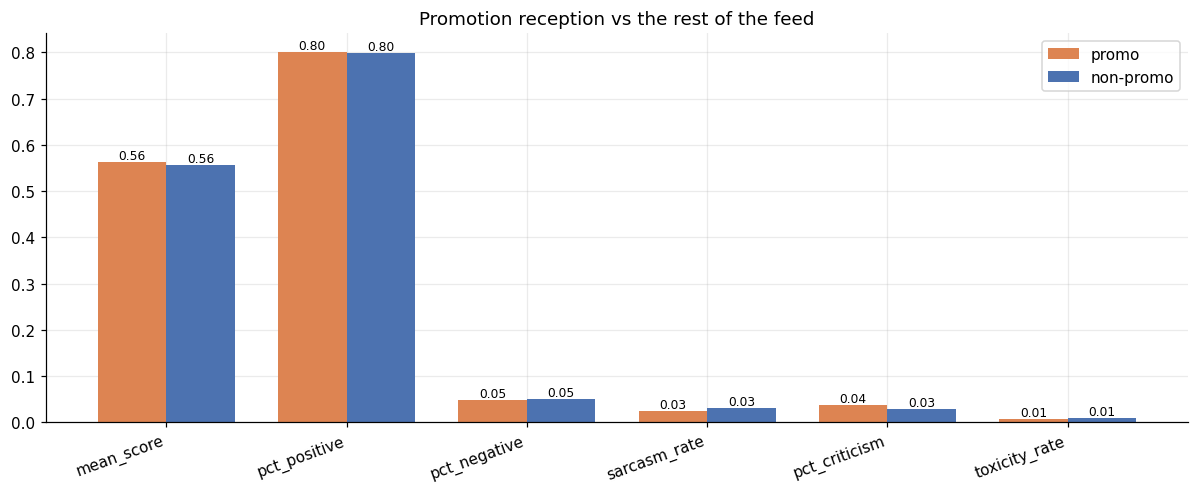

In [ ]:
# === Is the promotion received well? Promo vs the rest of the feed ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
if ps["is_promo"].sum() == 0:
    print("No promo comments analysed — skipping. (Raise MAX_COMMENTS / keep PRIORITIZE_MEDIA_POSTS.)")
else:
    def _stats(g):
        return pd.Series({
            "comments":      len(g),
            "mean_score":    g["sentiment_score"].mean(),
            "pct_positive":  (g["sentiment_cat"] == "positive").mean(),
            "pct_negative":  (g["sentiment_cat"] == "negative").mean(),
            "sarcasm_rate":  g["sarcasm"].fillna(False).mean(),
            "toxicity_rate": (g["toxicity"].fillna("none") != "none").mean(),
            "pct_criticism": (g["intent"] == "criticism").mean(),
            "pct_question":  (g["intent"] == "question").mean(),
        })
    comp = pd.DataFrame({"promo": _stats(ps[ps["is_promo"]]),
                         "non-promo": _stats(ps[~ps["is_promo"]])}).T
    print("Reception — promo vs non-promo:\n")
    print(comp.T.round(3).to_string())

    # Product-targeted comments under promo posts = the most direct read on the product itself.
    prod = ps[(ps["is_promo"]) & (ps["target"] == "product")]
    if len(prod):
        print(f"\nProduct-targeted comments under promo posts: {len(prod):,} | "
              f"mean score {prod['sentiment_score'].mean():+.3f} | "
              f"%pos {(prod['sentiment_cat']=='positive').mean():.0%} | "
              f"%neg {(prod['sentiment_cat']=='negative').mean():.0%}")
    d = comp.loc["promo", "mean_score"] - comp.loc["non-promo", "mean_score"]
    print(f"\nPromo posts run {('+' if d>=0 else '')}{d:.3f} in mean score vs the rest of the feed "
          f"({'better' if d>=0 else 'worse'} received).")

    metrics = ["mean_score", "pct_positive", "pct_negative", "sarcasm_rate", "pct_criticism", "toxicity_rate"]
    fig, ax = plt.subplots(figsize=(11, 4.6))
    x = np.arange(len(metrics)); w = 0.38
    ax.bar(x - w/2, comp.loc["promo", metrics].values,     w, label="promo",     color="#dd8452")
    ax.bar(x + w/2, comp.loc["non-promo", metrics].values, w, label="non-promo", color="#4c72b0")
    for i, m in enumerate(metrics):
        ax.text(i - w/2, comp.loc["promo", m],     f"{comp.loc['promo', m]:.2f}",     ha="center", va="bottom", fontsize=8)
        ax.text(i + w/2, comp.loc["non-promo", m], f"{comp.loc['non-promo', m]:.2f}", ha="center", va="bottom", fontsize=8)
    ax.axhline(0, color="k", lw=.6); ax.set_xticks(x); ax.set_xticklabels(metrics, rotation=20, ha="right")
    ax.legend(); ax.set_title("Promotion reception vs the rest of the feed")
    fig.tight_layout(); _psave(fig, "06_promo_vs_rest"); plt.show()

✅ 122 promo posts scored -> outputs/promo_reception_instagram.parquet
   reception: {'well_received': 93, 'mixed': 15, 'poorly_received': 14} 

=== Best-received promotions (n>=5) ===
   sponsor         promo_type  n_comments  vibe_score  pos_frac  neg_frac  sarcasm_rate     reception                                                                                                             caption_snip
           caption_disclosure           5    0.850000  1.000000       0.0           0.0 well_received Ho invitato alcuni di voi in DM per inaugurare con me la tana giochi arredata su @wallapop.it: ecco come è andata!  Vogl
           caption_disclosure           7    0.821429  1.000000       0.0           0.0 well_received Finalmente ci siamo amici, é con grande emozione che vi annuncio l’apertura del preorder per la mia nuova palette, prodo
   maxibon   paid_partnership           5    0.820000  1.000000       0.0           0.0 well_received Ripensando alla mia vita piena di pepe e di f

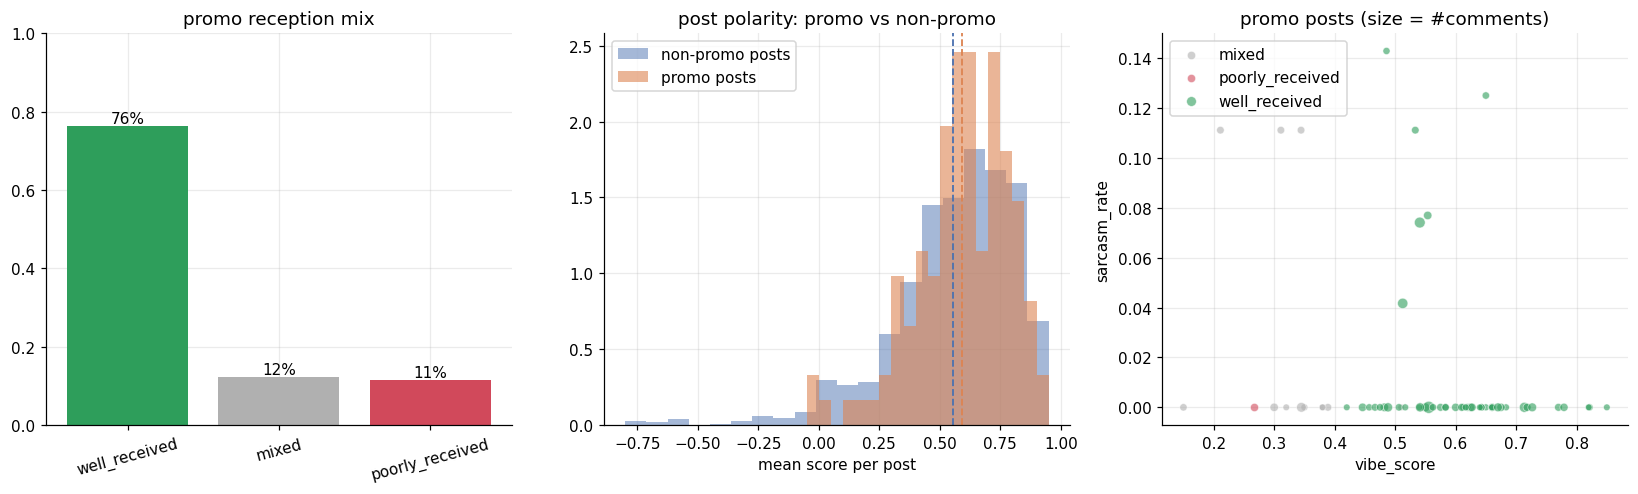

In [ ]:
# === Per-promotion reception: ranking + where the ads land ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
if ps["is_promo"].sum() == 0:
    print("No promo comments analysed — skipping.")
else:
    gp = ps[ps["is_promo"]].copy()
    gp["sarcasm"] = gp["sarcasm"].fillna(False)
    base = gp.groupby("media_id_n")
    promo = pd.DataFrame({
        "n_comments":   base.size(),
        "vibe_score":   base["sentiment_score"].mean(),
        "sarcasm_rate": base["sarcasm"].mean(),
    })
    cc = pd.crosstab(gp["media_id_n"], gp["sentiment_cat"], normalize="index")
    promo["pos_frac"] = cc["positive"] if "positive" in cc else 0.0
    promo["neg_frac"] = cc["negative"] if "negative" in cc else 0.0
    ic = pd.crosstab(gp["media_id_n"], gp["intent"], normalize="index")
    promo["criticism_rate"] = ic["criticism"] if "criticism" in ic else 0.0
    promo[["pos_frac", "neg_frac", "criticism_rate"]] = promo[["pos_frac", "neg_frac", "criticism_rate"]].fillna(0)
    promo["controversy"] = 4 * promo["pos_frac"] * promo["neg_frac"]
    promo = promo.reset_index().merge(
        mi[["media_id_n", "promo_type", "sponsor", "caption_snip", "permalink"]].drop_duplicates("media_id_n"),
        on="media_id_n", how="left")

    def _recv(r):
        if r["vibe_score"] >= 0.4 and r["neg_frac"] < 0.15 and r["sarcasm_rate"] < 0.15: return "well_received"
        if r["vibe_score"] < 0.1 or r["neg_frac"] >= 0.30 or r["sarcasm_rate"] >= 0.25:  return "poorly_received"
        return "mixed"
    promo["reception"] = promo.apply(_recv, axis=1)
    out = f"{LOCAL_DIR}/promo_reception_{PLATFORM}.parquet"; promo.to_parquet(out, index=False)
    print(f"✅ {len(promo):,} promo posts scored -> {out}")
    print("   reception:", promo["reception"].value_counts().to_dict(), "\n")

    view = promo[promo["n_comments"] >= 5]
    cols = [c for c in ["sponsor", "promo_type", "n_comments", "vibe_score", "pos_frac", "neg_frac",
                        "sarcasm_rate", "reception", "caption_snip"] if c in view.columns]
    print("=== Best-received promotions (n>=5) ===")
    print(view.sort_values("vibe_score", ascending=False).head(8)[cols].to_string(index=False))
    print("\n=== Worst-received promotions (n>=5) ===")
    print(view.sort_values("vibe_score", ascending=True).head(8)[cols].to_string(index=False))

    RECV_C = {"well_received": POS_C, "mixed": NEU_C, "poorly_received": NEG_C}
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
    # (a) reception label mix
    rl = promo["reception"].value_counts(normalize=True).reindex(
        ["well_received", "mixed", "poorly_received"]).fillna(0)
    ax[0].bar(rl.index, rl.values, color=[RECV_C[k] for k in rl.index])
    for i, v in enumerate(rl.values): ax[0].text(i, v, f"{v:.0%}", ha="center", va="bottom")
    ax[0].set_ylim(0, 1); ax[0].set_title("promo reception mix"); ax[0].tick_params(axis="x", rotation=15)
    # (b) per-post polarity: promo vs non-promo
    nonp = ps[~ps["is_promo"]].groupby("media_id_n")["sentiment_score"].mean()
    if len(nonp): ax[1].hist(nonp.dropna(), bins=20, density=True, alpha=.5, color="#4c72b0", label="non-promo posts")
    ax[1].hist(promo["vibe_score"].dropna(), bins=20, density=True, alpha=.6, color="#dd8452", label="promo posts")
    ax[1].axvline(promo["vibe_score"].mean(), color="#dd8452", ls="--", lw=1.2)
    if len(nonp): ax[1].axvline(nonp.mean(), color="#4c72b0", ls="--", lw=1.2)
    ax[1].set_xlabel("mean score per post"); ax[1].set_title("post polarity: promo vs non-promo"); ax[1].legend()
    # (c) where ads land: polarity vs sarcasm, size=#comments, colour=reception
    for rcv, d in view.groupby("reception"):
        ax[2].scatter(d["vibe_score"], d["sarcasm_rate"], s=d["n_comments"].clip(upper=200) * 1.4 + 12,
                      c=RECV_C.get(rcv, "#777"), alpha=.6, edgecolor="white", linewidth=.5, label=rcv)
    ax[2].set_xlabel("vibe_score"); ax[2].set_ylabel("sarcasm_rate")
    ax[2].set_title("promo posts (size = #comments)"); ax[2].legend()
    fig.tight_layout(); _psave(fig, "07_promo_reception"); plt.show()

In [ ]:
mixed_posts = promo[promo.reception == "mixed"]

In [ ]:
mixed_posts.columns

Index(['media_id_n', 'n_comments', 'vibe_score', 'sarcasm_rate', 'pos_frac',
       'neg_frac', 'criticism_rate', 'controversy', 'promo_type', 'sponsor',
       'caption_snip', 'permalink', 'reception'],
      dtype='object')

In [ ]:
# Find comments from mixed-reception posts
mixed_post_ids = promo[promo["reception"] == "mixed"]["media_id_n"].unique()
mixed_comments = sent[sent["media_id"].isin(mixed_post_ids)][["media_id", "text", "sentiment_score", "sentiment_cat", "emotion", "target", "intent"]].copy()

print(f"Mixed-reception posts: {len(mixed_post_ids)}")
print(f"Total comments from mixed posts: {len(mixed_comments)}\n")

# Group by post to see sentiment breakdown per mixed post
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

for mid in mixed_post_ids[:5]:  # show first 5
    post_comms = mixed_comments[mixed_comments["media_id"] == mid]
    print(f"\n{'='*120}")
    print(f"Post {mid} — {len(post_comms)} comments")
    print('='*120)
    display(post_comms[["text", "sentiment_score", "sentiment_cat", "emotion", "target", "intent"]])


Mixed-reception posts: 15
Total comments from mixed posts: 113


Post 17846734825258779 — 6 comments


,text,sentiment_score,sentiment_cat,emotion,target,intent
200,"💛 sei di una bellezza indescrivibile, altro che trent’anni",0.8,positive,amusement,content_work,joke
9654,@rugen83 😍,0.7,positive,joy,appearance,affection
9655,@caravalentina_ molto,0.1,neutral,neutral,other_user,other
9656,👌🏻,0.1,neutral,neutral,content_work,other
9657,Vovi di pitona👌,0.8,positive,joy,appearance,praise
9658,Ma la punteggiatura no???,-0.4,negative,disgust,content_work,criticism



Post 17866748908569226 — 5 comments


,text,sentiment_score,sentiment_cat,emotion,target,intent
3575,@valerialiscio nusco se non erro le abbiamo comprate lí si,0.0,neutral,neutral,none,tag_share
7015,@armenia.cotardo vero!! Quando potremo la ordineremo senz’altro!! Speriamo presto,0.4,positive,anticipation,content_work,support
7016,"Se ti hanno regalato la loro consulenza ok, perché da più di una persona ho sentito che sono carissimi... anche se bravi!!",-0.3,negative,disgust,product,criticism
7017,"il letto sembra bellissimo 😍, dove lo avete trovato? @camihawke @aimoneromizi",0.7,positive,joy,content_work,praise
7018,Complimentiiiiiiiii..,0.8,positive,joy,content_work,praise



Post 17873195980896580 — 4 comments


,text,sentiment_score,sentiment_cat,emotion,target,intent
1996,Belle😍,0.6,positive,admiration,other_user,tag_share
6848,Che belle che siete,0.7,positive,joy,appearance,praise
6849,"@camihawke tu sei troppo bella per poter avere un potere sulla sensibilizzazione dei nostri difetti (nostri intendo del tutto il mondo femminile) . Finché le grandi aziende e i big dei social andranno alla ricerca di “immagini” come la tua per fare campagne del genere, temo che lo scopo non verrà mai raggiunto. -",-0.6,negative,sadness,content_work,criticism
6850,Ahahahahah 😂 io quando entro in acqua e sento qualcosa sotto i piedi \n\nSiete super carine 🥰❤️,0.7,positive,joy,appearance,joke



Post 17928564961421370 — 5 comments


,text,sentiment_score,sentiment_cat,emotion,target,intent
2957,@_marechiaro @alessiapenna_ numeri su iPod e come chiamarli,-0.4,negative,fear,content_work,other
6534,Zaino top,0.7,positive,joy,product,praise
6535,"@camihawke ricordo di aver pensato qualcosa di misto tra ""oddio oddio oddio"" e ""cretina cretina cretina""😂",0.4,positive,joy,creator,support
6536,Io ho abbandonato volontariamente delle scarpe in un ostello sul cammino di santiago...il giorno dopo mi hanno fatto raggiungere da un pellegrino cinese per riportarmi le scarpe😅 carini i pellegrini ma alla fine le ho riabbandonate di nuovo😅,0.3,positive,joy,creator,other
6537,"Cami una di noi, se non ci fossi ti dovrebbero inventare! 😘",0.9,positive,joy,creator,praise



Post 17938722839417074 — 2 comments


,text,sentiment_score,sentiment_cat,emotion,target,intent
1455,@agne.montanaro ❤️,0.1,neutral,amusement,content_work,joke
1456,Io definisco uguale l’estate 😂😂😂,0.6,positive,approval,content_work,praise
